# Assignment 1 - Group 3

# Index
- [Exploratory Data Analysis](#initial-exploration)
- [Feature Engineering](#feature-engineering)
- [Experiment](#experiment)
- [Results](#result)



<a id='data-loading'></a>
### 0. DATASET LOADING 

In [ ]:
from utils.constants import *
from utils.histogram_computation import *
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC
import pandas as pd
import shutil
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import os
import warnings
from scipy import stats
from scipy.stats import skew, kurtosis
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from tqdm import tqdm
from skimage.feature import local_binary_pattern
import kagglehub

#RUN THIS CELL, NECESSARY IMPORTS
#pip install kagglehub[pandas-datasets] to download dataset
os.makedirs('gtrsb_dataset', exist_ok=True)
dataset_path = kagglehub.dataset_download("meowmeowmeowmeowmeow/gtsrb-german-traffic-sign")
print(f"Dataset downloaded to: {dataset_path}")

# move the dataset to current project directory
target_path = './gtrsb_dataset'
if os.path.exists(target_path):
    shutil.move(dataset_path, target_path)


pd.read_csv(os.path.join(DF_PATH, 'Test.csv'))


train_df = pd.read_csv(os.path.join(DF_PATH, 'Train.csv'))
test_df = pd.read_csv(os.path.join(DF_PATH, 'Test.csv'))
meta_df = pd.read_csv(os.path.join(DF_PATH, 'Meta.csv'))

df = pd.concat([train_df, test_df])

### 1. INITIAL EXPLORATION <a id='initial-exploration'>

In [3]:
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 8)
plt.rcParams['font.size'] = 10


# ============================================================================
# 1. DATA LOADING & INITIAL EXPLORATION
# ============================================================================

print("="*80)
print("GERMAN TRAFFIC SIGN RECOGNITION DATASET - COMPREHENSIVE EDA")
print("="*80)



print("\n" + "="*80)
print("1. BASIC INFORMATION")
print("="*80)

print("\n📋 Dataset Info:")
print(df.info())

print("\n📊 First 10 rows:")
print(df.head(10))

print("\n📊 Last 10 rows:")
print(df.tail(10))

print("\n📈 Statistical Summary:")
print(df.describe())

print("\n🔍 Data Types:")
print(df.dtypes)

print("\n❓ Missing Values:")
print(df.isnull().sum())

print("\n🔢 Duplicate Rows:")
print(f"Number of duplicates: {df.duplicated().sum()}")


GERMAN TRAFFIC SIGN RECOGNITION DATASET - COMPREHENSIVE EDA

1. BASIC INFORMATION

📋 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
Index: 51839 entries, 0 to 12629
Data columns (total 8 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Width    51839 non-null  int64 
 1   Height   51839 non-null  int64 
 2   Roi.X1   51839 non-null  int64 
 3   Roi.Y1   51839 non-null  int64 
 4   Roi.X2   51839 non-null  int64 
 5   Roi.Y2   51839 non-null  int64 
 6   ClassId  51839 non-null  int64 
 7   Path     51839 non-null  object
dtypes: int64(7), object(1)
memory usage: 3.6+ MB
None

📊 First 10 rows:
   Width  Height  Roi.X1  Roi.Y1  Roi.X2  Roi.Y2  ClassId  \
0     27      26       5       5      22      20       20   
1     28      27       5       6      23      22       20   
2     29      26       6       5      24      21       20   
3     28      27       5       6      23      22       20   
4     28      26       5       5      23      21  

### 2. CLASS DISTRIBUTION ANALYSIS


2. CLASS DISTRIBUTION ANALYSIS

📊 Number of unique classes: 43
Total samples: 51839

Class distribution:
ClassId
0      270
1     2940
2     3000
3     1860
4     2640
5     2490
6      570
7     1890
8     1860
9     1950
10    2670
11    1740
12    2790
13    2880
14    1050
15     840
16     570
17    1470
18    1590
19     270
20     450
21     420
22     510
23     660
24     360
25    1980
26     780
27     300
28     690
29     360
30     600
31    1050
32     300
33     899
34     540
35    1590
36     510
37     270
38    2760
39     390
40     450
41     300
42     330
Name: count, dtype: int64

📊 Class Statistics:
Mean samples per class: 1205.56
Median samples per class: 780.00
Std samples per class: 929.07
Min samples: 270 (Class 0)
Max samples: 3000 (Class 2)
Imbalance ratio: 11.11x

✅ Saved: 01_class_distribution.png


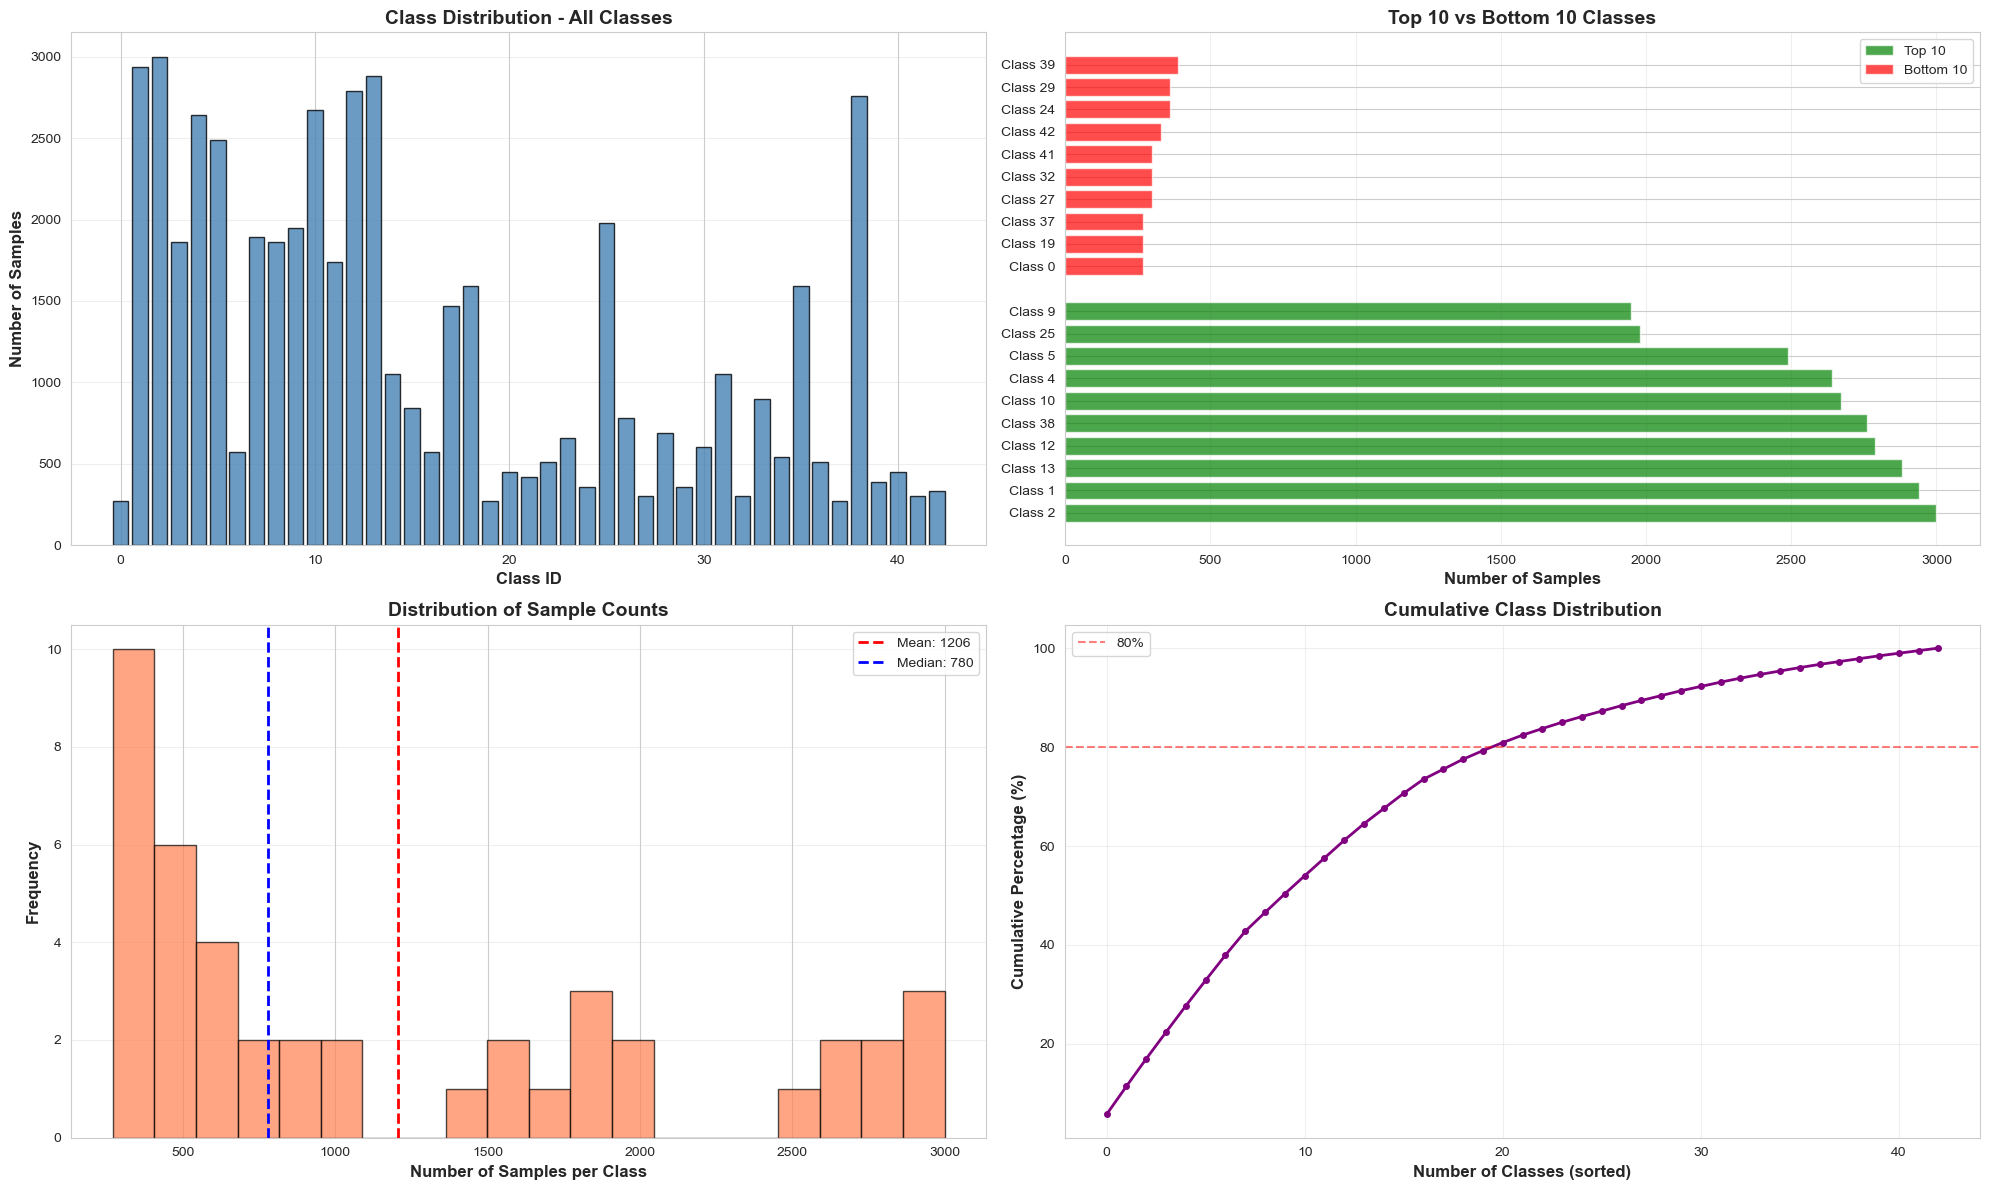

In [4]:
# ============================================================================
# 2. CLASS DISTRIBUTION ANALYSIS
# ============================================================================

print("\n" + "="*80)
print("2. CLASS DISTRIBUTION ANALYSIS")
print("="*80)

class_counts = df['ClassId'].value_counts().sort_index()
print(f"\n📊 Number of unique classes: {df['ClassId'].nunique()}")
print(f"Total samples: {len(df)}")
print(f"\nClass distribution:")
print(class_counts)

print(f"\n📊 Class Statistics:")
print(f"Mean samples per class: {class_counts.mean():.2f}")
print(f"Median samples per class: {class_counts.median():.2f}")
print(f"Std samples per class: {class_counts.std():.2f}")
print(f"Min samples: {class_counts.min()} (Class {class_counts.idxmin()})")
print(f"Max samples: {class_counts.max()} (Class {class_counts.idxmax()})")
print(f"Imbalance ratio: {class_counts.max() / class_counts.min():.2f}x")

# Visualize class distribution
fig, axes = plt.subplots(2, 2, figsize=(20, 12))

# Plot 1: Bar chart of class distribution
axes[0, 0].bar(class_counts.index, class_counts.values, color='steelblue', alpha=0.8, edgecolor='black')
axes[0, 0].set_xlabel('Class ID', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Number of Samples', fontsize=12, fontweight='bold')
axes[0, 0].set_title('Class Distribution - All Classes', fontsize=14, fontweight='bold')
axes[0, 0].grid(axis='y', alpha=0.3)

# Plot 2: Top 10 and Bottom 10 classes
top_10 = class_counts.nlargest(10)
bottom_10 = class_counts.nsmallest(10)
x = range(10)
axes[0, 1].barh(x, top_10.values, color='green', alpha=0.7, label='Top 10')
axes[0, 1].barh([i+11 for i in x], bottom_10.values, color='red', alpha=0.7, label='Bottom 10')
axes[0, 1].set_yticks(list(x) + [i+11 for i in x])
axes[0, 1].set_yticklabels([f"Class {c}" for c in top_10.index] + [f"Class {c}" for c in bottom_10.index])
axes[0, 1].set_xlabel('Number of Samples', fontsize=12, fontweight='bold')
axes[0, 1].set_title('Top 10 vs Bottom 10 Classes', fontsize=14, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(axis='x', alpha=0.3)

# Plot 3: Histogram of class counts
axes[1, 0].hist(class_counts.values, bins=20, color='coral', alpha=0.7, edgecolor='black')
axes[1, 0].set_xlabel('Number of Samples per Class', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[1, 0].set_title('Distribution of Sample Counts', fontsize=14, fontweight='bold')
axes[1, 0].axvline(class_counts.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {class_counts.mean():.0f}')
axes[1, 0].axvline(class_counts.median(), color='blue', linestyle='--', linewidth=2, label=f'Median: {class_counts.median():.0f}')
axes[1, 0].legend()
axes[1, 0].grid(axis='y', alpha=0.3)

# Plot 4: Cumulative distribution
sorted_counts = class_counts.sort_values(ascending=False)
cumulative = sorted_counts.cumsum() / sorted_counts.sum() * 100
axes[1, 1].plot(range(len(cumulative)), cumulative.values, marker='o', linewidth=2, markersize=4, color='purple')
axes[1, 1].set_xlabel('Number of Classes (sorted)', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Cumulative Percentage (%)', fontsize=12, fontweight='bold')
axes[1, 1].set_title('Cumulative Class Distribution', fontsize=14, fontweight='bold')
axes[1, 1].grid(alpha=0.3)
axes[1, 1].axhline(80, color='red', linestyle='--', alpha=0.5, label='80%')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('01_class_distribution.png', dpi=300, bbox_inches='tight')
print("\n✅ Saved: 01_class_distribution.png")
plt.show()

### 3. IMAGE DIMENSIONS ANALYSIS


3. IMAGE DIMENSIONS ANALYSIS

📏 Width Statistics:
count    51839.000000
mean        50.755937
std         24.499807
min         25.000000
25%         34.000000
50%         43.000000
75%         58.000000
max        266.000000
Name: Width, dtype: float64
Skewness: 2.1715
Kurtosis: 6.3842

📏 Height Statistics:
count    51839.000000
mean        50.337584
std         23.258706
min         25.000000
25%         35.000000
50%         43.000000
75%         58.000000
max        232.000000
Name: Height, dtype: float64
Skewness: 2.0472
Kurtosis: 5.4498

📐 Aspect Ratio Statistics:
count    51839.000000
mean         1.005629
std          0.073384
min          0.368132
25%          0.970588
50%          1.000000
75%          1.038462
max          1.437500
Name: AspectRatio, dtype: float64

📦 Area Statistics:
count    51839.000000
mean      3113.525049
std       3731.174984
min        625.000000
25%       1190.000000
50%       1849.000000
75%       3310.500000
max      61712.000000
Name: Area, dtyp

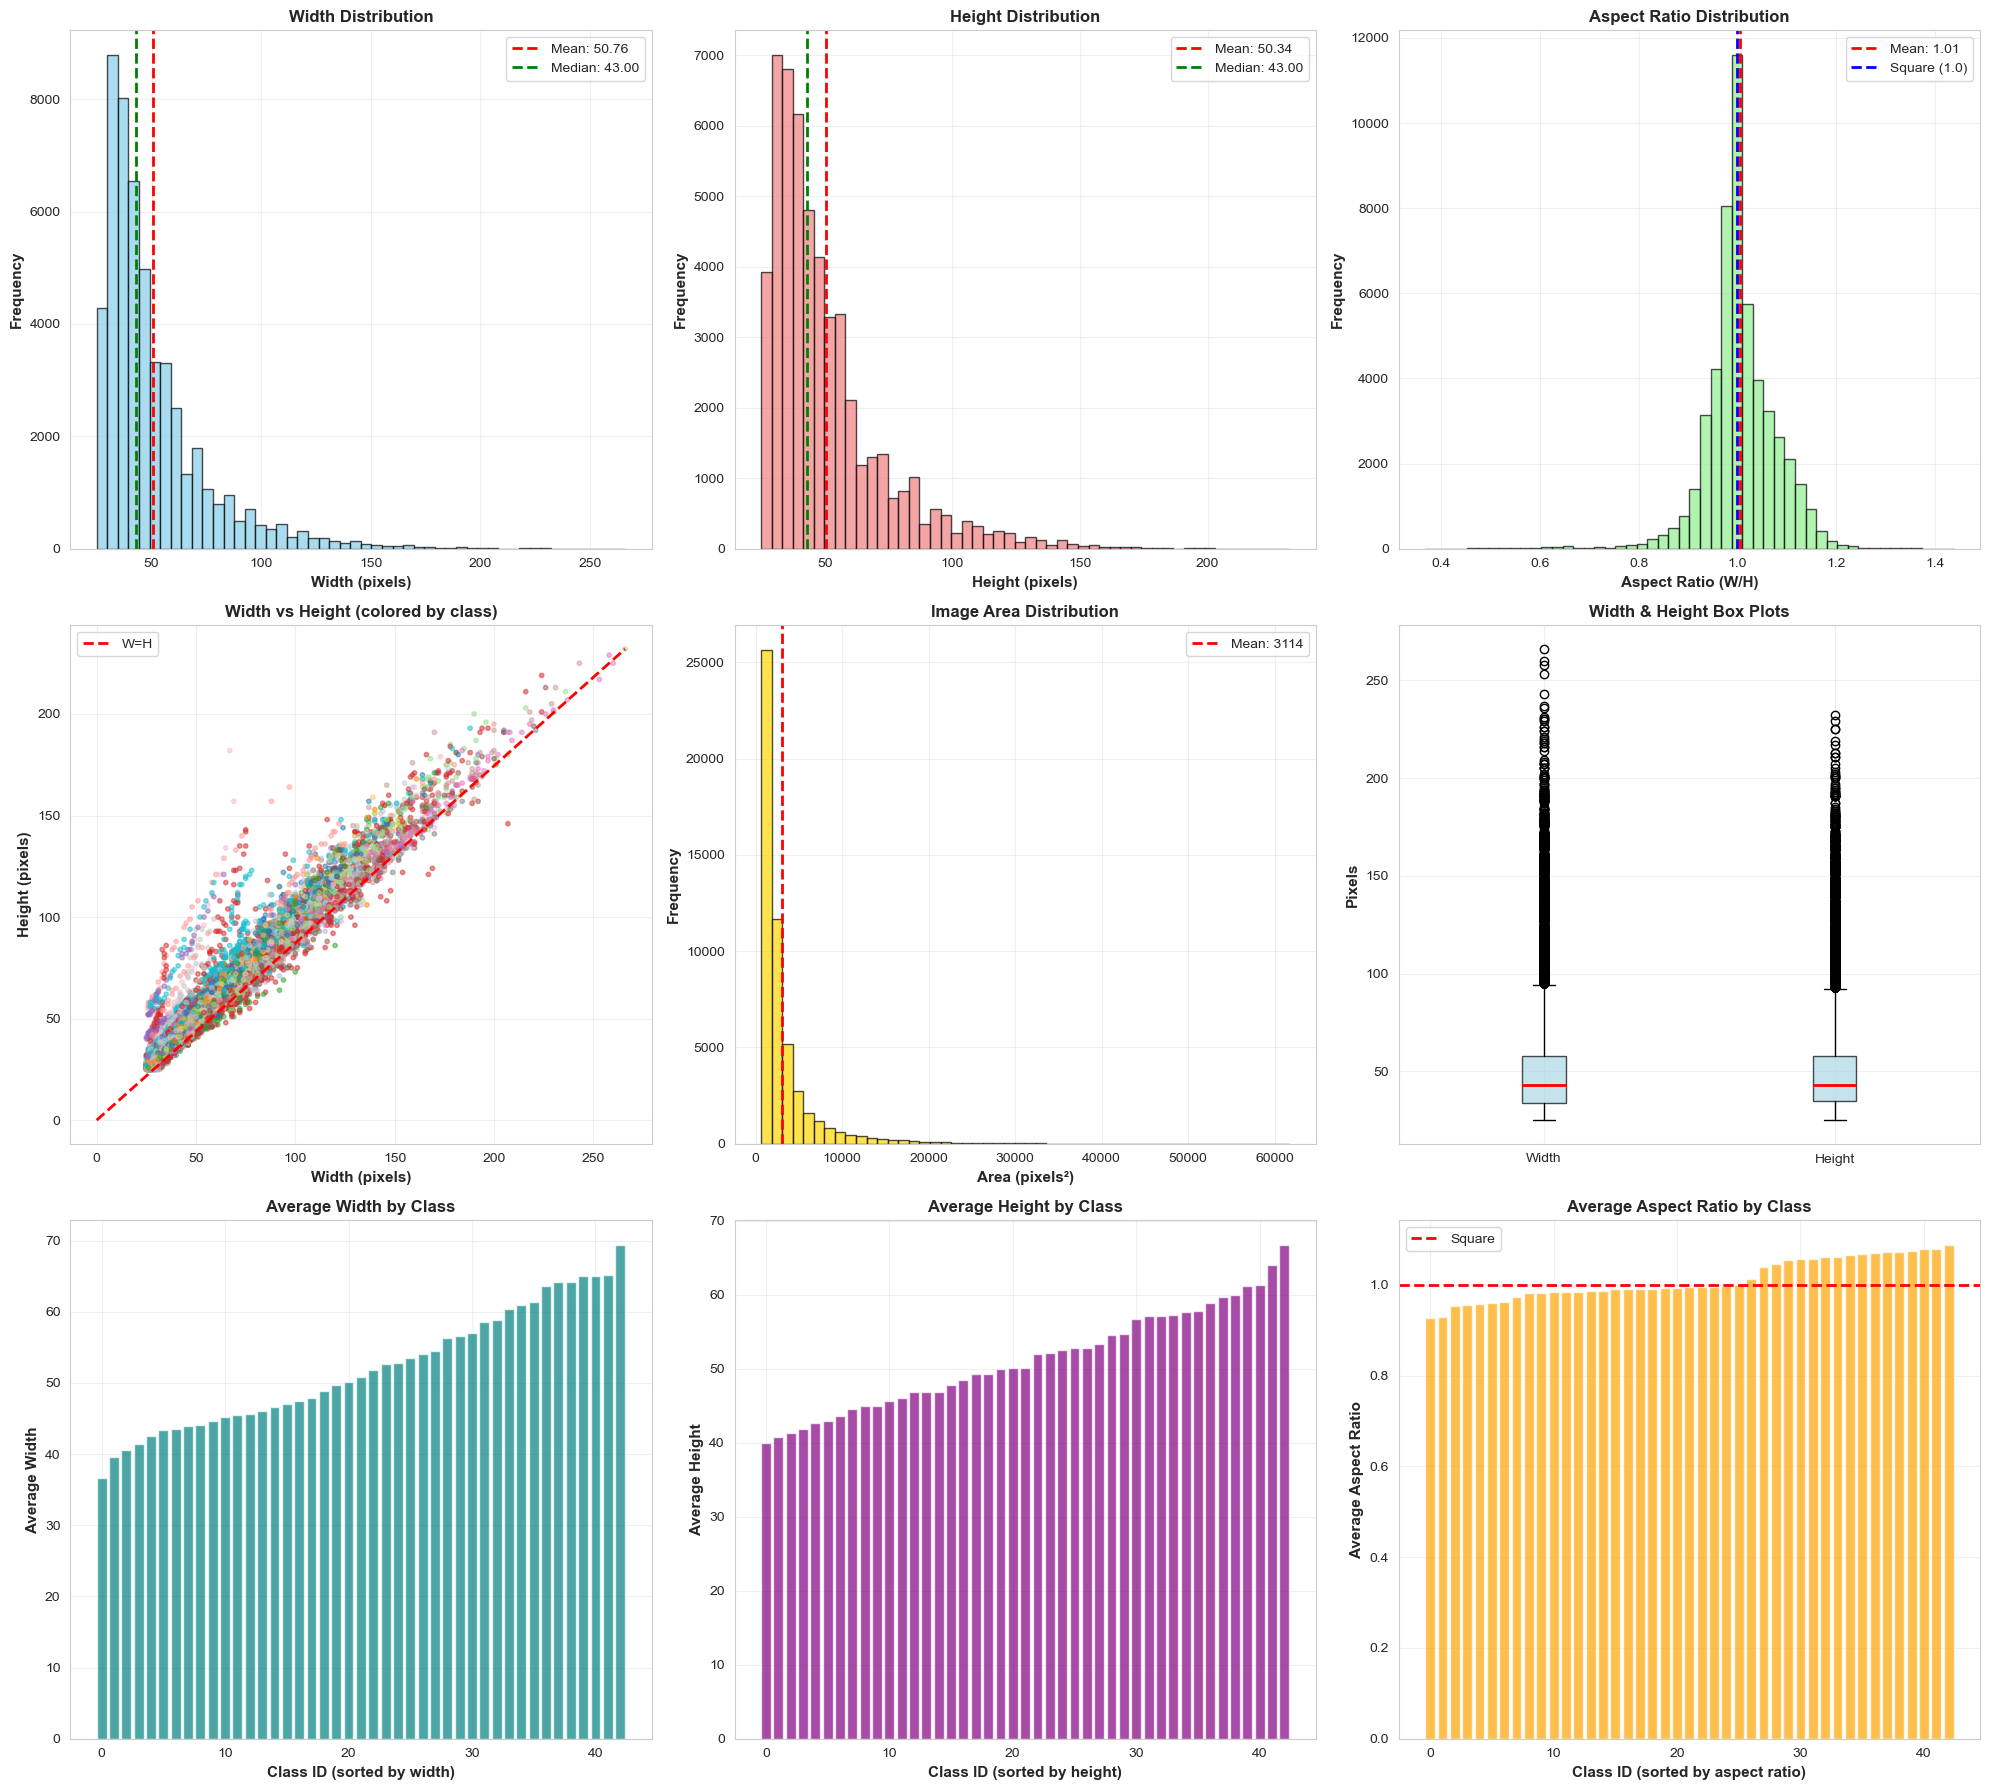

In [5]:

# ============================================================================
# 3. IMAGE DIMENSIONS ANALYSIS
# ============================================================================

print("\n" + "="*80)
print("3. IMAGE DIMENSIONS ANALYSIS")
print("="*80)

# Calculate additional metrics
df['AspectRatio'] = df['Width'] / df['Height']
df['Area'] = df['Width'] * df['Height']
df['Perimeter'] = 2 * (df['Width'] + df['Height'])

print("\n📏 Width Statistics:")
print(df['Width'].describe())
print(f"Skewness: {skew(df['Width']):.4f}")
print(f"Kurtosis: {kurtosis(df['Width']):.4f}")

print("\n📏 Height Statistics:")
print(df['Height'].describe())
print(f"Skewness: {skew(df['Height']):.4f}")
print(f"Kurtosis: {kurtosis(df['Height']):.4f}")

print("\n📐 Aspect Ratio Statistics:")
print(df['AspectRatio'].describe())

print("\n📦 Area Statistics:")
print(df['Area'].describe())

fig, axes = plt.subplots(3, 3, figsize=(20, 18))

# Plot 1: Width distribution
axes[0, 0].hist(df['Width'], bins=50, color='skyblue', alpha=0.7, edgecolor='black')
axes[0, 0].axvline(df['Width'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["Width"].mean():.2f}')
axes[0, 0].axvline(df['Width'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {df["Width"].median():.2f}')
axes[0, 0].set_xlabel('Width (pixels)', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[0, 0].set_title('Width Distribution', fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Plot 2: Height distribution
axes[0, 1].hist(df['Height'], bins=50, color='lightcoral', alpha=0.7, edgecolor='black')
axes[0, 1].axvline(df['Height'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["Height"].mean():.2f}')
axes[0, 1].axvline(df['Height'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {df["Height"].median():.2f}')
axes[0, 1].set_xlabel('Height (pixels)', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[0, 1].set_title('Height Distribution', fontsize=12, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Plot 3: Aspect Ratio distribution
axes[0, 2].hist(df['AspectRatio'], bins=50, color='lightgreen', alpha=0.7, edgecolor='black')
axes[0, 2].axvline(df['AspectRatio'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["AspectRatio"].mean():.2f}')
axes[0, 2].axvline(1.0, color='blue', linestyle='--', linewidth=2, label='Square (1.0)')
axes[0, 2].set_xlabel('Aspect Ratio (W/H)', fontsize=11, fontweight='bold')
axes[0, 2].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[0, 2].set_title('Aspect Ratio Distribution', fontsize=12, fontweight='bold')
axes[0, 2].legend()
axes[0, 2].grid(alpha=0.3)

# Plot 4: Width vs Height scatter
scatter = axes[1, 0].scatter(df['Width'], df['Height'], c=df['ClassId'], cmap='tab20', alpha=0.5, s=10)
axes[1, 0].plot([0, df['Width'].max()], [0, df['Height'].max()], 'r--', linewidth=2, label='W=H')
axes[1, 0].set_xlabel('Width (pixels)', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Height (pixels)', fontsize=11, fontweight='bold')
axes[1, 0].set_title('Width vs Height (colored by class)', fontsize=12, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Plot 5: Area distribution
axes[1, 1].hist(df['Area'], bins=50, color='gold', alpha=0.7, edgecolor='black')
axes[1, 1].axvline(df['Area'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["Area"].mean():.0f}')
axes[1, 1].set_xlabel('Area (pixels²)', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[1, 1].set_title('Image Area Distribution', fontsize=12, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

# Plot 6: Box plots for Width and Height
box_data = [df['Width'], df['Height']]
bp = axes[1, 2].boxplot(box_data, labels=['Width', 'Height'], patch_artist=True, 
                         boxprops=dict(facecolor='lightblue', alpha=0.7),
                         medianprops=dict(color='red', linewidth=2))
axes[1, 2].set_ylabel('Pixels', fontsize=11, fontweight='bold')
axes[1, 2].set_title('Width & Height Box Plots', fontsize=12, fontweight='bold')
axes[1, 2].grid(alpha=0.3)

# Plot 7: Width by Class
class_width = df.groupby('ClassId')['Width'].mean().sort_values()
axes[2, 0].bar(range(len(class_width)), class_width.values, color='teal', alpha=0.7)
axes[2, 0].set_xlabel('Class ID (sorted by width)', fontsize=11, fontweight='bold')
axes[2, 0].set_ylabel('Average Width', fontsize=11, fontweight='bold')
axes[2, 0].set_title('Average Width by Class', fontsize=12, fontweight='bold')
axes[2, 0].grid(alpha=0.3)

# Plot 8: Height by Class
class_height = df.groupby('ClassId')['Height'].mean().sort_values()
axes[2, 1].bar(range(len(class_height)), class_height.values, color='purple', alpha=0.7)
axes[2, 1].set_xlabel('Class ID (sorted by height)', fontsize=11, fontweight='bold')
axes[2, 1].set_ylabel('Average Height', fontsize=11, fontweight='bold')
axes[2, 1].set_title('Average Height by Class', fontsize=12, fontweight='bold')
axes[2, 1].grid(alpha=0.3)

# Plot 9: Aspect Ratio by Class
class_ar = df.groupby('ClassId')['AspectRatio'].mean().sort_values()
axes[2, 2].bar(range(len(class_ar)), class_ar.values, color='orange', alpha=0.7)
axes[2, 2].axhline(1.0, color='red', linestyle='--', linewidth=2, label='Square')
axes[2, 2].set_xlabel('Class ID (sorted by aspect ratio)', fontsize=11, fontweight='bold')
axes[2, 2].set_ylabel('Average Aspect Ratio', fontsize=11, fontweight='bold')
axes[2, 2].set_title('Average Aspect Ratio by Class', fontsize=12, fontweight='bold')
axes[2, 2].legend()
axes[2, 2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('02_dimensions_analysis.png', dpi=300, bbox_inches='tight')
print("\n✅ Saved: 02_dimensions_analysis.png")
plt.show()


### 4. ROI (Region of Interest) ANALYSIS


4. ROI ANALYSIS

📍 ROI Statistics:

Roi.X1:
count    51839.000000
mean         5.999151
std          1.492448
min          0.000000
25%          5.000000
50%          6.000000
75%          6.000000
max         23.000000
Name: Roi.X1, dtype: float64

Roi.Y1:
count    51839.000000
mean         5.967264
std          1.395798
min          5.000000
25%          5.000000
50%          6.000000
75%          6.000000
max         20.000000
Name: Roi.Y1, dtype: float64

Roi.X2:
count    51839.000000
mean        45.116206
std         23.236830
min         20.000000
25%         29.000000
50%         38.000000
75%         53.000000
max        244.000000
Name: Roi.X2, dtype: float64

Roi.Y2:
count    51839.000000
mean        44.735624
std         22.099631
min         20.000000
25%         30.000000
50%         38.000000
75%         52.000000
max        212.000000
Name: Roi.Y2, dtype: float64

ROI_Width:
count    51839.000000
mean        39.117055
std         21.980593
min         15.000000
25%     

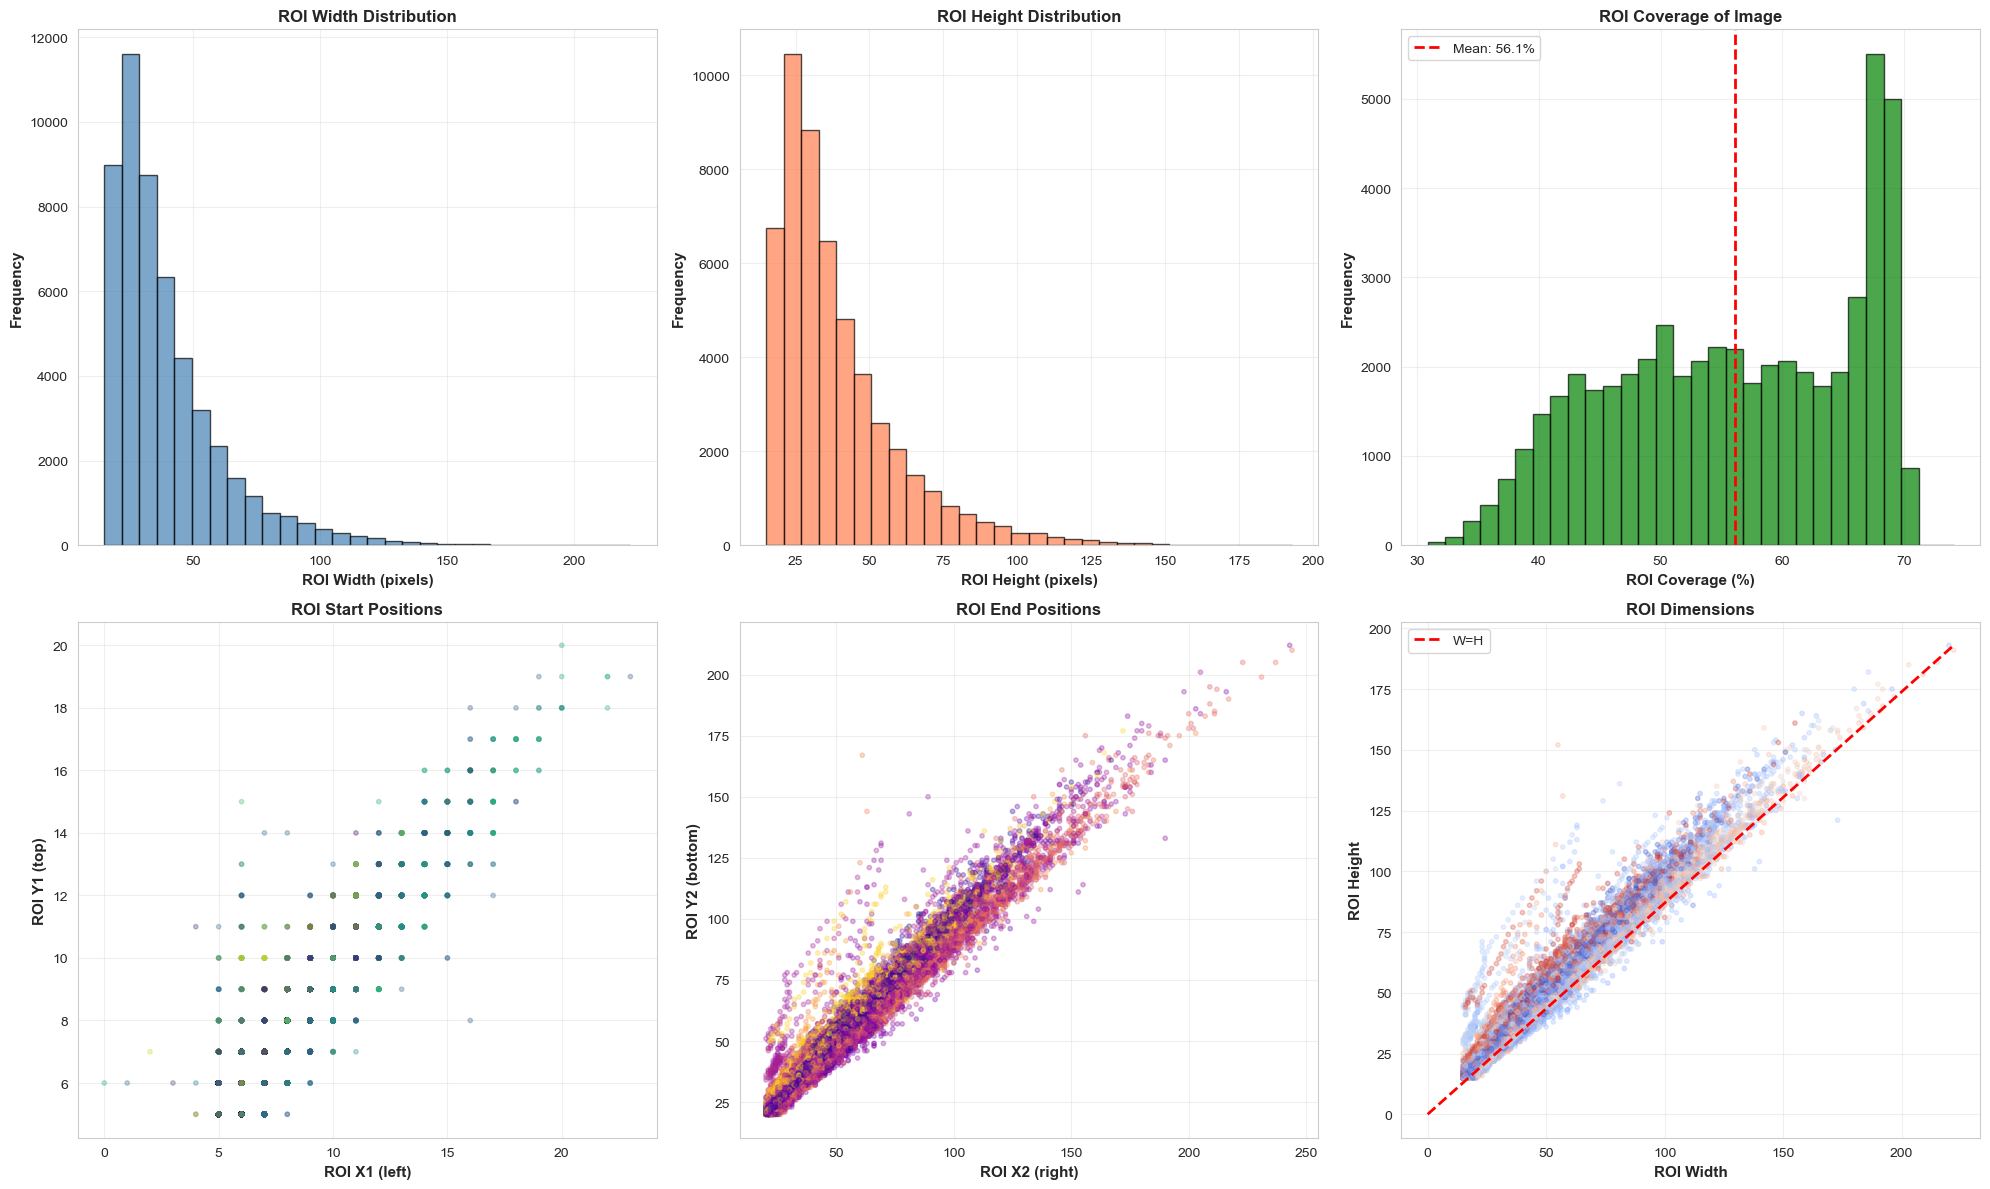

In [6]:
# ============================================================================
# 4. ROI (Region of Interest) ANALYSIS
# ============================================================================

print("\n" + "="*80)
print("4. ROI ANALYSIS")
print("="*80)

# Calculate ROI metrics
df['ROI_Width'] = df['Roi.X2'] - df['Roi.X1']
df['ROI_Height'] = df['Roi.Y2'] - df['Roi.Y1']
df['ROI_Area'] = df['ROI_Width'] * df['ROI_Height']
df['ROI_Coverage'] = (df['ROI_Area'] / df['Area']) * 100  # Percentage of image

print("\n📍 ROI Statistics:")
for col in ['Roi.X1', 'Roi.Y1', 'Roi.X2', 'Roi.Y2', 'ROI_Width', 'ROI_Height', 'ROI_Coverage']:
    print(f"\n{col}:")
    print(df[col].describe())

fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# Plot 1: ROI Width distribution
axes[0, 0].hist(df['ROI_Width'], bins=30, color='steelblue', alpha=0.7, edgecolor='black')
axes[0, 0].set_xlabel('ROI Width (pixels)', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[0, 0].set_title('ROI Width Distribution', fontsize=12, fontweight='bold')
axes[0, 0].grid(alpha=0.3)

# Plot 2: ROI Height distribution
axes[0, 1].hist(df['ROI_Height'], bins=30, color='coral', alpha=0.7, edgecolor='black')
axes[0, 1].set_xlabel('ROI Height (pixels)', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[0, 1].set_title('ROI Height Distribution', fontsize=12, fontweight='bold')
axes[0, 1].grid(alpha=0.3)

# Plot 3: ROI Coverage
axes[0, 2].hist(df['ROI_Coverage'], bins=30, color='green', alpha=0.7, edgecolor='black')
axes[0, 2].axvline(df['ROI_Coverage'].mean(), color='red', linestyle='--', linewidth=2, 
                   label=f'Mean: {df["ROI_Coverage"].mean():.1f}%')
axes[0, 2].set_xlabel('ROI Coverage (%)', fontsize=11, fontweight='bold')
axes[0, 2].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[0, 2].set_title('ROI Coverage of Image', fontsize=12, fontweight='bold')
axes[0, 2].legend()
axes[0, 2].grid(alpha=0.3)

# Plot 4: ROI Start positions
axes[1, 0].scatter(df['Roi.X1'], df['Roi.Y1'], alpha=0.3, s=10, c=df['ClassId'], cmap='viridis')
axes[1, 0].set_xlabel('ROI X1 (left)', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('ROI Y1 (top)', fontsize=11, fontweight='bold')
axes[1, 0].set_title('ROI Start Positions', fontsize=12, fontweight='bold')
axes[1, 0].grid(alpha=0.3)

# Plot 5: ROI End positions
axes[1, 1].scatter(df['Roi.X2'], df['Roi.Y2'], alpha=0.3, s=10, c=df['ClassId'], cmap='plasma')
axes[1, 1].set_xlabel('ROI X2 (right)', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('ROI Y2 (bottom)', fontsize=11, fontweight='bold')
axes[1, 1].set_title('ROI End Positions', fontsize=12, fontweight='bold')
axes[1, 1].grid(alpha=0.3)

# Plot 6: ROI Width vs Height
axes[1, 2].scatter(df['ROI_Width'], df['ROI_Height'], alpha=0.3, s=10, c=df['ClassId'], cmap='coolwarm')
axes[1, 2].plot([0, df['ROI_Width'].max()], [0, df['ROI_Height'].max()], 'r--', linewidth=2, label='W=H')
axes[1, 2].set_xlabel('ROI Width', fontsize=11, fontweight='bold')
axes[1, 2].set_ylabel('ROI Height', fontsize=11, fontweight='bold')
axes[1, 2].set_title('ROI Dimensions', fontsize=12, fontweight='bold')
axes[1, 2].legend()
axes[1, 2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('03_roi_analysis.png', dpi=300, bbox_inches='tight')
print("\n✅ Saved: 03_roi_analysis.png")
plt.show()


### 5. CORRELATION ANALYSIS


5. CORRELATION ANALYSIS

📊 Correlation Matrix:
                 Width    Height    Roi.X1    Roi.Y1    Roi.X2    Roi.Y2  \
Width         1.000000  0.980294  0.861066  0.826527  0.999562  0.979712   
Height        0.980294  1.000000  0.829427  0.846960  0.980480  0.999551   
Roi.X1        0.861066  0.829427  1.000000  0.847759  0.851090  0.819548   
Roi.Y1        0.826527  0.846960  0.847759  1.000000  0.817153  0.836563   
Roi.X2        0.999562  0.980480  0.851090  0.817153  1.000000  0.980591   
Roi.Y2        0.979712  0.999551  0.819548  0.836563  0.980591  1.000000   
AspectRatio   0.255913  0.079097  0.251942  0.014445  0.256216  0.079674   
Area          0.958953  0.951048  0.910516  0.896983  0.952888  0.944529   
ROI_Width     0.998224  0.980199  0.831833  0.806294  0.999364  0.980987   
ROI_Height    0.978597  0.998167  0.808196  0.816004  0.980148  0.999333   
ROI_Coverage  0.758203  0.766610  0.390359  0.383462  0.774317  0.782554   

              AspectRatio      Area  RO

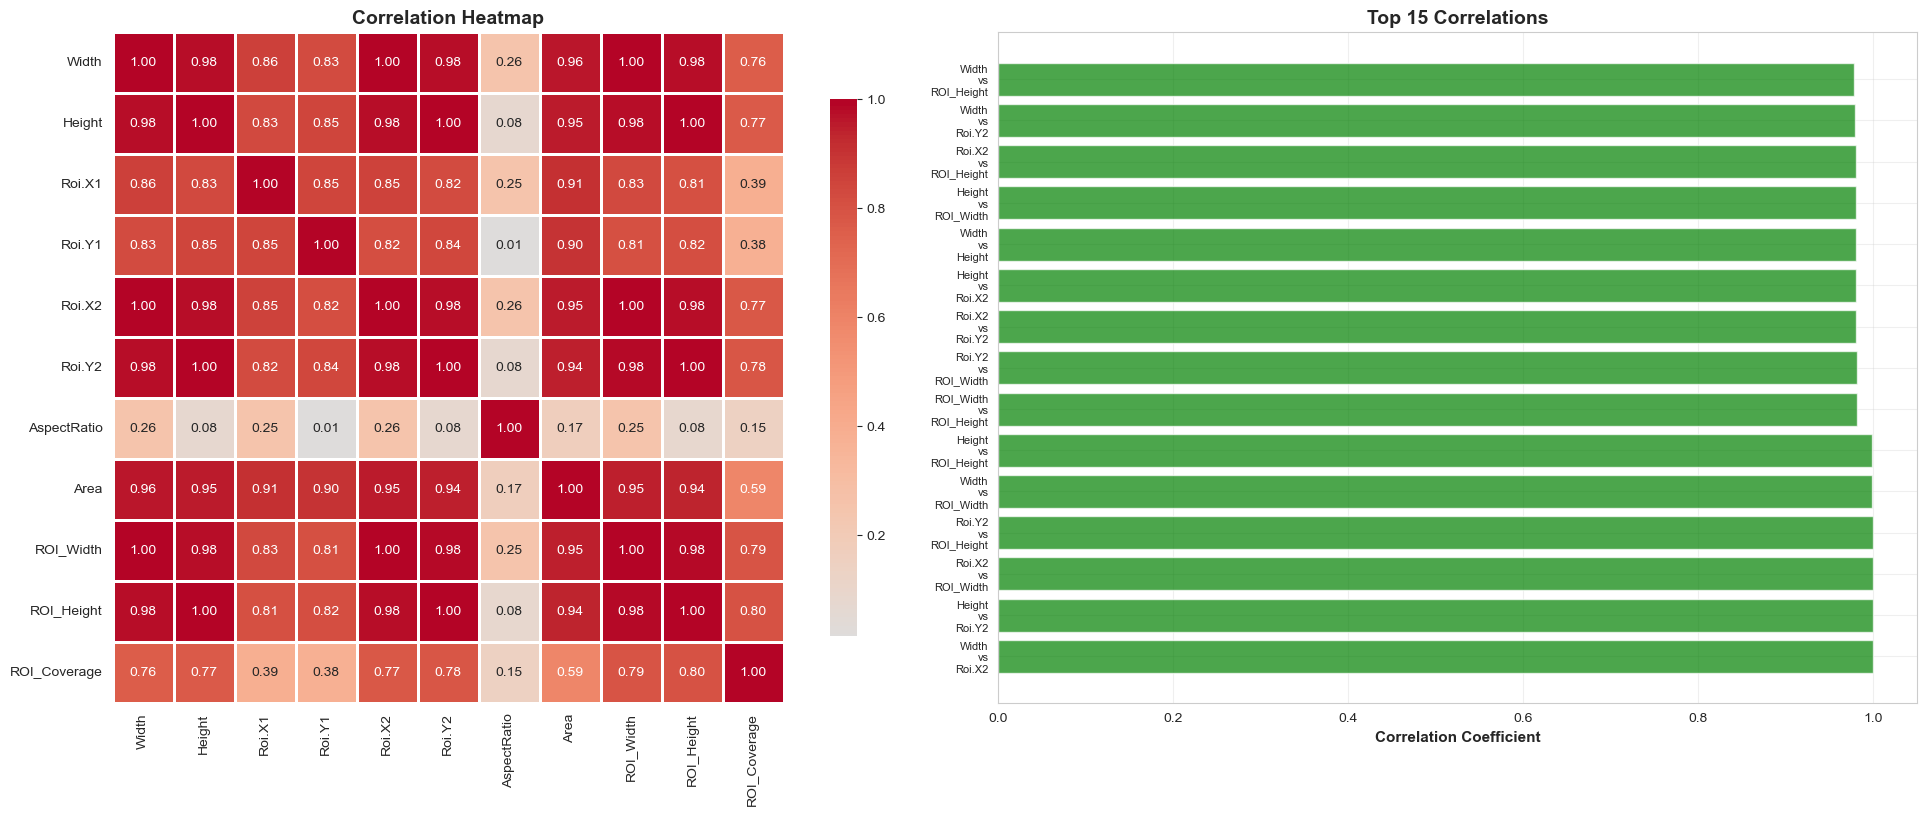

In [7]:
# ============================================================================
# 5. CORRELATION ANALYSIS
# ============================================================================

print("\n" + "="*80)
print("5. CORRELATION ANALYSIS")
print("="*80)

# Select numerical columns
numerical_cols = ['Width', 'Height', 'Roi.X1', 'Roi.Y1', 'Roi.X2', 'Roi.Y2', 
                  'AspectRatio', 'Area', 'ROI_Width', 'ROI_Height', 'ROI_Coverage']

correlation_matrix = df[numerical_cols].corr()

print("\n📊 Correlation Matrix:")
print(correlation_matrix)

# Find strongest correlations
correlation_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        correlation_pairs.append({
            'Feature 1': correlation_matrix.columns[i],
            'Feature 2': correlation_matrix.columns[j],
            'Correlation': correlation_matrix.iloc[i, j]
        })

correlation_df = pd.DataFrame(correlation_pairs).sort_values('Correlation', ascending=False, key=abs)
print("\n🔝 Top 10 Strongest Correlations:")
print(correlation_df.head(10))

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Heatmap
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=axes[0])
axes[0].set_title('Correlation Heatmap', fontsize=14, fontweight='bold')

# Correlation bar plot (top correlations)
top_corr = correlation_df.head(15)
y_labels = [f"{row['Feature 1']}\nvs\n{row['Feature 2']}" for _, row in top_corr.iterrows()]
colors = ['green' if x > 0 else 'red' for x in top_corr['Correlation']]
axes[1].barh(range(len(top_corr)), top_corr['Correlation'], color=colors, alpha=0.7)
axes[1].set_yticks(range(len(top_corr)))
axes[1].set_yticklabels(y_labels, fontsize=8)
axes[1].set_xlabel('Correlation Coefficient', fontsize=11, fontweight='bold')
axes[1].set_title('Top 15 Correlations', fontsize=14, fontweight='bold')
axes[1].axvline(0, color='black', linewidth=0.5)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('04_correlation_analysis.png', dpi=300, bbox_inches='tight')
print("\n✅ Saved: 04_correlation_analysis.png")
plt.show()


### 6. CLASS-WISE DETAILED ANALYSIS


6. CLASS-WISE DETAILED ANALYSIS

📊 Class-wise Statistics (first 10 classes):
         Width_mean  Width_std  Width_min  Width_max  Height_mean  Height_std  \
ClassId                                                                         
0             50.83      22.17         27        144        51.99       23.11   
1             51.89      21.79         25        182        52.78       22.22   
2             46.58      20.08         25        171        46.80       19.98   
3             44.08      18.50         25        151        44.95       19.18   
4             45.66      18.71         25        159        45.97       18.71   
5             42.49      15.99         25        161        42.70       16.32   
6             39.63      12.44         25         98        41.32       13.17   
7             43.91      17.60         25        176        44.56       17.81   
8             43.47      15.24         25        148        43.57       15.47   
9             47.88      20.52 

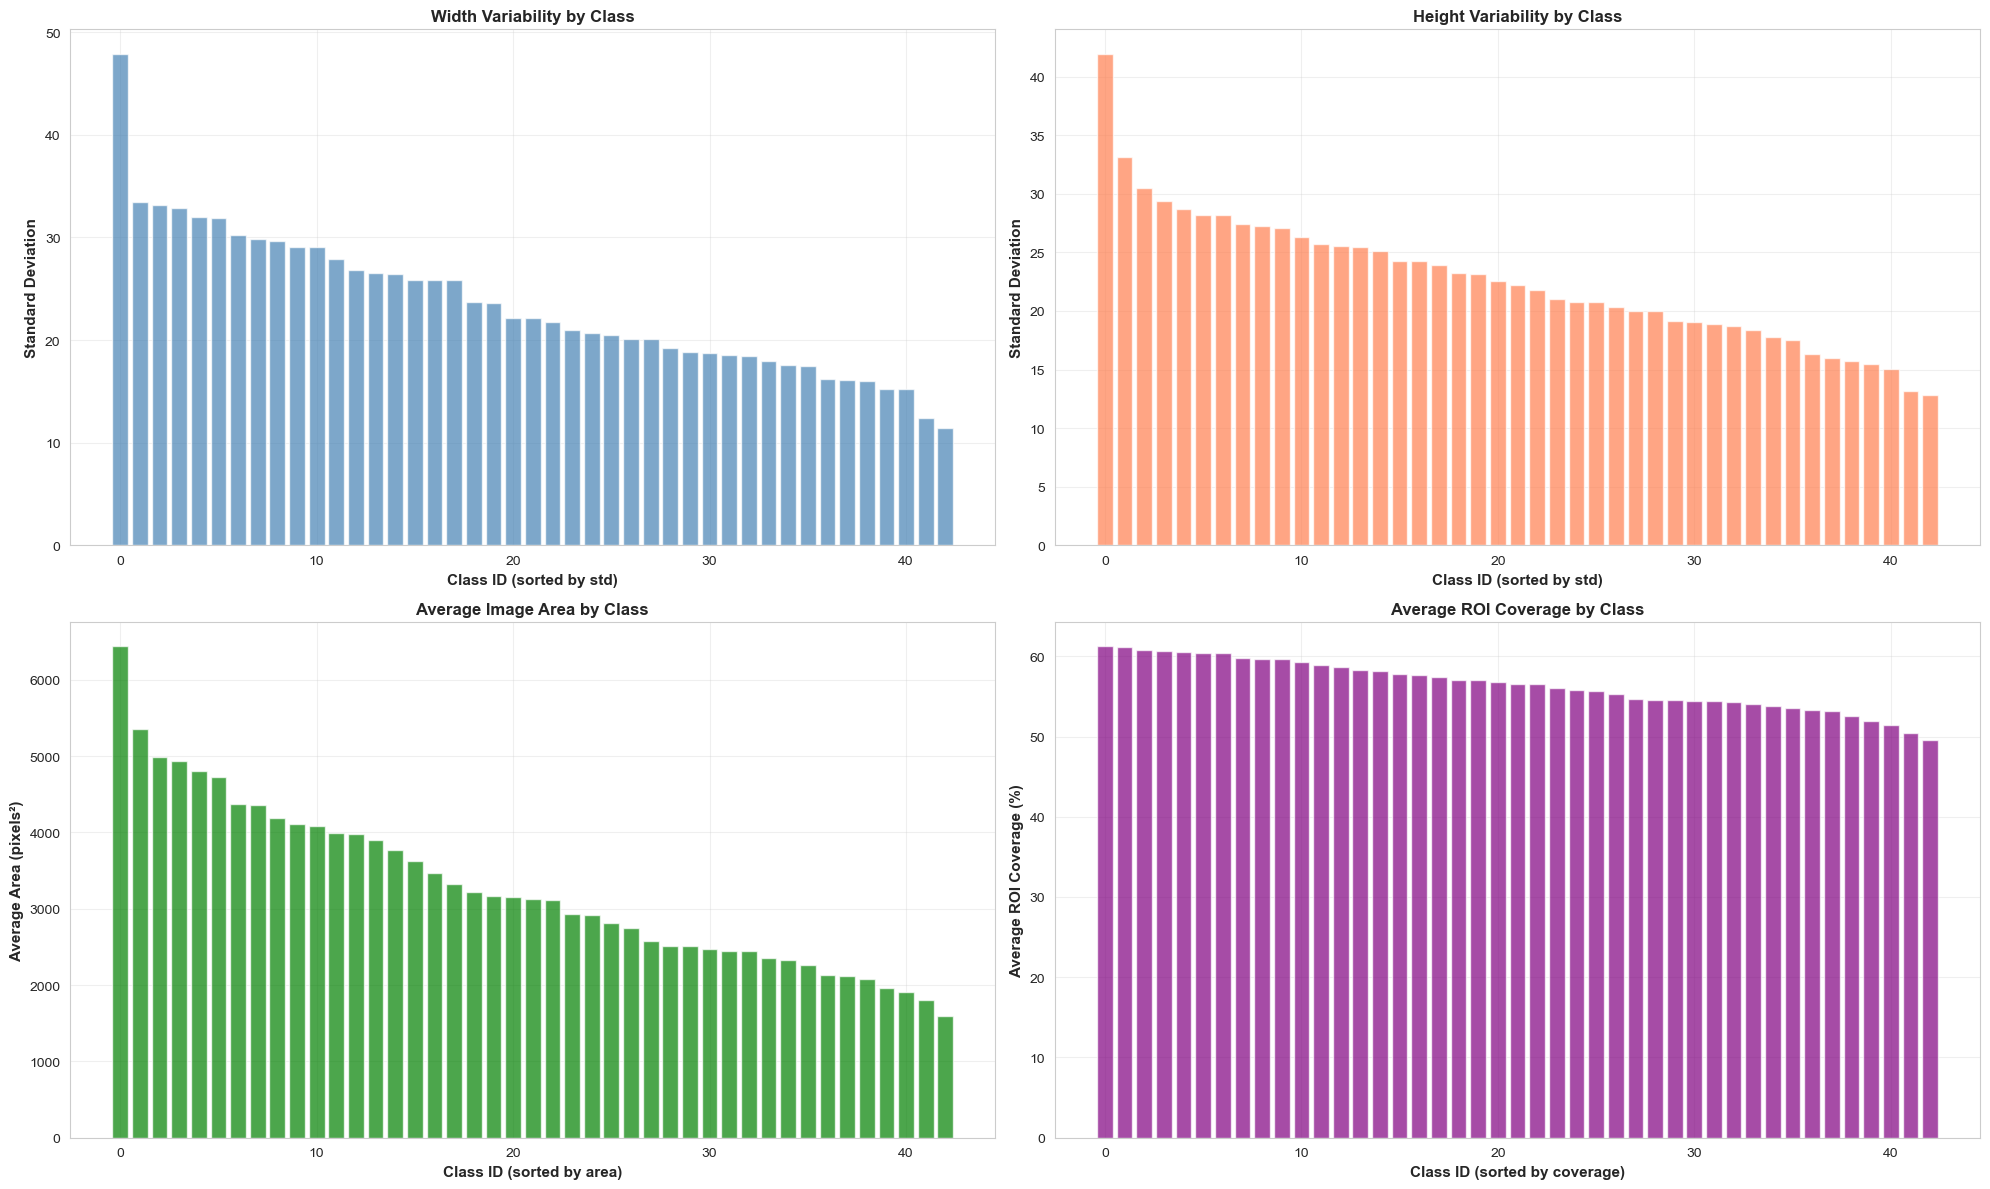

In [8]:
# ============================================================================
# 6. CLASS-WISE DETAILED ANALYSIS
# ============================================================================

print("\n" + "="*80)
print("6. CLASS-WISE DETAILED ANALYSIS")
print("="*80)

class_stats = df.groupby('ClassId').agg({
    'Width': ['mean', 'std', 'min', 'max'],
    'Height': ['mean', 'std', 'min', 'max'],
    'Area': ['mean', 'std'],
    'AspectRatio': ['mean', 'std'],
    'ROI_Coverage': ['mean', 'std'],
    'ClassId': 'count'
}).round(2)

class_stats.columns = ['_'.join(col).strip() for col in class_stats.columns.values]
class_stats = class_stats.rename(columns={'ClassId_count': 'Sample_Count'})

print("\n📊 Class-wise Statistics (first 10 classes):")
print(class_stats.head(10))

# Save to CSV
class_stats.to_csv('class_statistics.csv')
print("\n✅ Saved: class_statistics.csv")

fig, axes = plt.subplots(2, 2, figsize=(20, 12))

# Plot 1: Variability in Width by Class
class_width_std = df.groupby('ClassId')['Width'].std().sort_values(ascending=False)
axes[0, 0].bar(range(len(class_width_std)), class_width_std.values, color='steelblue', alpha=0.7)
axes[0, 0].set_xlabel('Class ID (sorted by std)', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Standard Deviation', fontsize=11, fontweight='bold')
axes[0, 0].set_title('Width Variability by Class', fontsize=12, fontweight='bold')
axes[0, 0].grid(alpha=0.3)

# Plot 2: Variability in Height by Class
class_height_std = df.groupby('ClassId')['Height'].std().sort_values(ascending=False)
axes[0, 1].bar(range(len(class_height_std)), class_height_std.values, color='coral', alpha=0.7)
axes[0, 1].set_xlabel('Class ID (sorted by std)', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('Standard Deviation', fontsize=11, fontweight='bold')
axes[0, 1].set_title('Height Variability by Class', fontsize=12, fontweight='bold')
axes[0, 1].grid(alpha=0.3)

# Plot 3: Average Area by Class
class_area = df.groupby('ClassId')['Area'].mean().sort_values(ascending=False)
axes[1, 0].bar(range(len(class_area)), class_area.values, color='green', alpha=0.7)
axes[1, 0].set_xlabel('Class ID (sorted by area)', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Average Area (pixels²)', fontsize=11, fontweight='bold')
axes[1, 0].set_title('Average Image Area by Class', fontsize=12, fontweight='bold')
axes[1, 0].grid(alpha=0.3)

# Plot 4: ROI Coverage by Class
class_roi = df.groupby('ClassId')['ROI_Coverage'].mean().sort_values(ascending=False)
axes[1, 1].bar(range(len(class_roi)), class_roi.values, color='purple', alpha=0.7)
axes[1, 1].set_xlabel('Class ID (sorted by coverage)', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('Average ROI Coverage (%)', fontsize=11, fontweight='bold')
axes[1, 1].set_title('Average ROI Coverage by Class', fontsize=12, fontweight='bold')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('05_classwise_analysis.png', dpi=300, bbox_inches='tight')
print("\n✅ Saved: 05_classwise_analysis.png")
plt.show()


### 7. OUTLIER DETECTION


7. OUTLIER DETECTION

📌 Width:
  Outliers detected: 3370 (6.50%)
  Lower bound: -2.00, Upper bound: 94.00

📌 Height:
  Outliers detected: 3367 (6.50%)
  Lower bound: 0.50, Upper bound: 92.50

📌 Area:
  Outliers detected: 5312 (10.25%)
  Lower bound: -1990.75, Upper bound: 6491.25

📌 AspectRatio:
  Outliers detected: 3046 (5.88%)
  Lower bound: 0.87, Upper bound: 1.14

📌 ROI_Coverage:
  Outliers detected: 0 (0.00%)
  Lower bound: 20.26, Upper bound: 93.74

✅ Saved: 06_outlier_detection.png


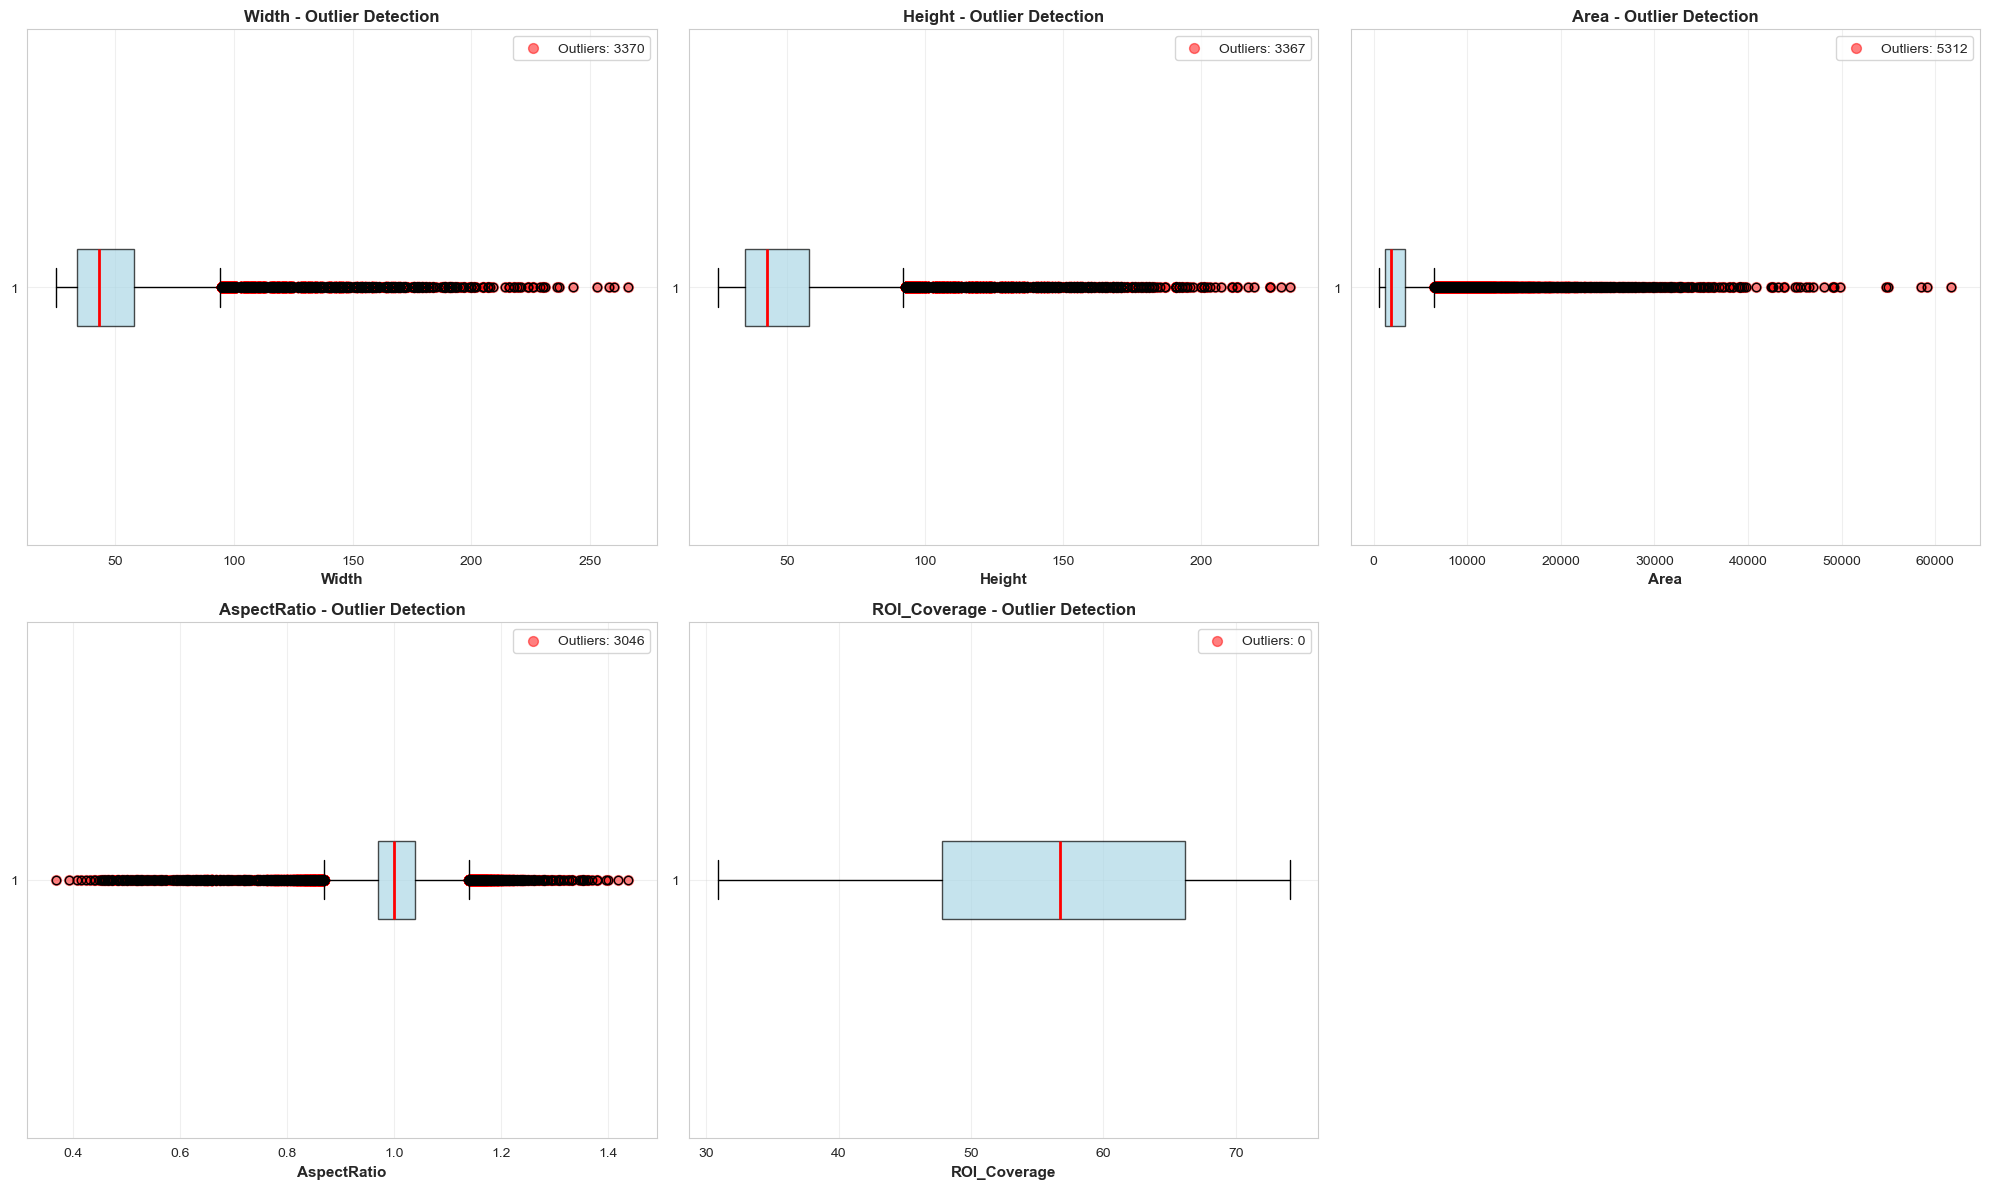

In [9]:
# ============================================================================
# 7. OUTLIER DETECTION
# ============================================================================

print("\n" + "="*80)
print("7. OUTLIER DETECTION")
print("="*80)

def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

features_to_check = ['Width', 'Height', 'Area', 'AspectRatio', 'ROI_Coverage']

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.ravel()

for idx, feature in enumerate(features_to_check):
    outliers, lower, upper = detect_outliers_iqr(df, feature)
    print(f"\n📌 {feature}:")
    print(f"  Outliers detected: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")
    print(f"  Lower bound: {lower:.2f}, Upper bound: {upper:.2f}")
    
    # Box plot with outliers highlighted
    axes[idx].boxplot(df[feature], vert=False, patch_artist=True,
                      boxprops=dict(facecolor='lightblue', alpha=0.7),
                      medianprops=dict(color='red', linewidth=2))
    axes[idx].scatter(outliers[feature], [1]*len(outliers), color='red', s=50, 
                      alpha=0.5, label=f'Outliers: {len(outliers)}')
    axes[idx].set_xlabel(feature, fontsize=11, fontweight='bold')
    axes[idx].set_title(f'{feature} - Outlier Detection', fontsize=12, fontweight='bold')
    axes[idx].legend()
    axes[idx].grid(alpha=0.3)

# Remove extra subplot
fig.delaxes(axes[5])

plt.tight_layout()
plt.savefig('06_outlier_detection.png', dpi=300, bbox_inches='tight')
print("\n✅ Saved: 06_outlier_detection.png")
plt.show()


### 8. STATISTICAL TESTS

In [10]:
# ============================================================================
# 8. STATISTICAL TESTS
# ============================================================================

print("\n" + "="*80)
print("8. STATISTICAL TESTS")
print("="*80)

# Normality tests
print("\n📊 Normality Tests (Shapiro-Wilk):")
for col in ['Width', 'Height', 'Area', 'AspectRatio']:
    if len(df[col]) > 5000:  # Sample for large datasets
        sample = df[col].sample(5000, random_state=42)
    else:
        sample = df[col]
    stat, p_value = stats.shapiro(sample)
    print(f"{col}: statistic={stat:.4f}, p-value={p_value:.4e}")
    if p_value > 0.05:
        print(f"  → {col} appears to be normally distributed (p > 0.05)")
    else:
        print(f"  → {col} does NOT appear normally distributed (p < 0.05)")

# ANOVA test - Are dimensions significantly different across classes?
print("\n📊 ANOVA Test - Dimensions across Classes:")
classes_sample = df['ClassId'].unique()[:10]  # Test on first 10 classes
for feature in ['Width', 'Height', 'Area']:
    groups = [df[df['ClassId'] == c][feature].values for c in classes_sample]
    f_stat, p_value = stats.f_oneway(*groups)
    print(f"\n{feature}:")
    print(f"  F-statistic: {f_stat:.4f}")
    print(f"  P-value: {p_value:.4e}")
    if p_value < 0.05:
        print(f"  → Significant difference in {feature} across classes (p < 0.05)")
    else:
        print(f"  → No significant difference in {feature} across classes (p > 0.05)")
        



8. STATISTICAL TESTS

📊 Normality Tests (Shapiro-Wilk):
Width: statistic=0.7964, p-value=6.3556e-62
  → Width does NOT appear normally distributed (p < 0.05)
Height: statistic=0.8095, p-value=1.1207e-60
  → Height does NOT appear normally distributed (p < 0.05)
Area: statistic=0.5935, p-value=9.7285e-76
  → Area does NOT appear normally distributed (p < 0.05)
AspectRatio: statistic=0.9225, p-value=5.1894e-45
  → AspectRatio does NOT appear normally distributed (p < 0.05)

📊 ANOVA Test - Dimensions across Classes:

Width:
  F-statistic: 61.0200
  P-value: 9.2042e-111
  → Significant difference in Width across classes (p < 0.05)

Height:
  F-statistic: 64.0128
  P-value: 2.3064e-116
  → Significant difference in Height across classes (p < 0.05)

Area:
  F-statistic: 48.2858
  P-value: 6.9578e-87
  → Significant difference in Area across classes (p < 0.05)


### 9. ADVANCED VISUALIZATIONS


9. ADVANCED VISUALIZATIONS

✅ Saved: 07_advanced_visualizations.png


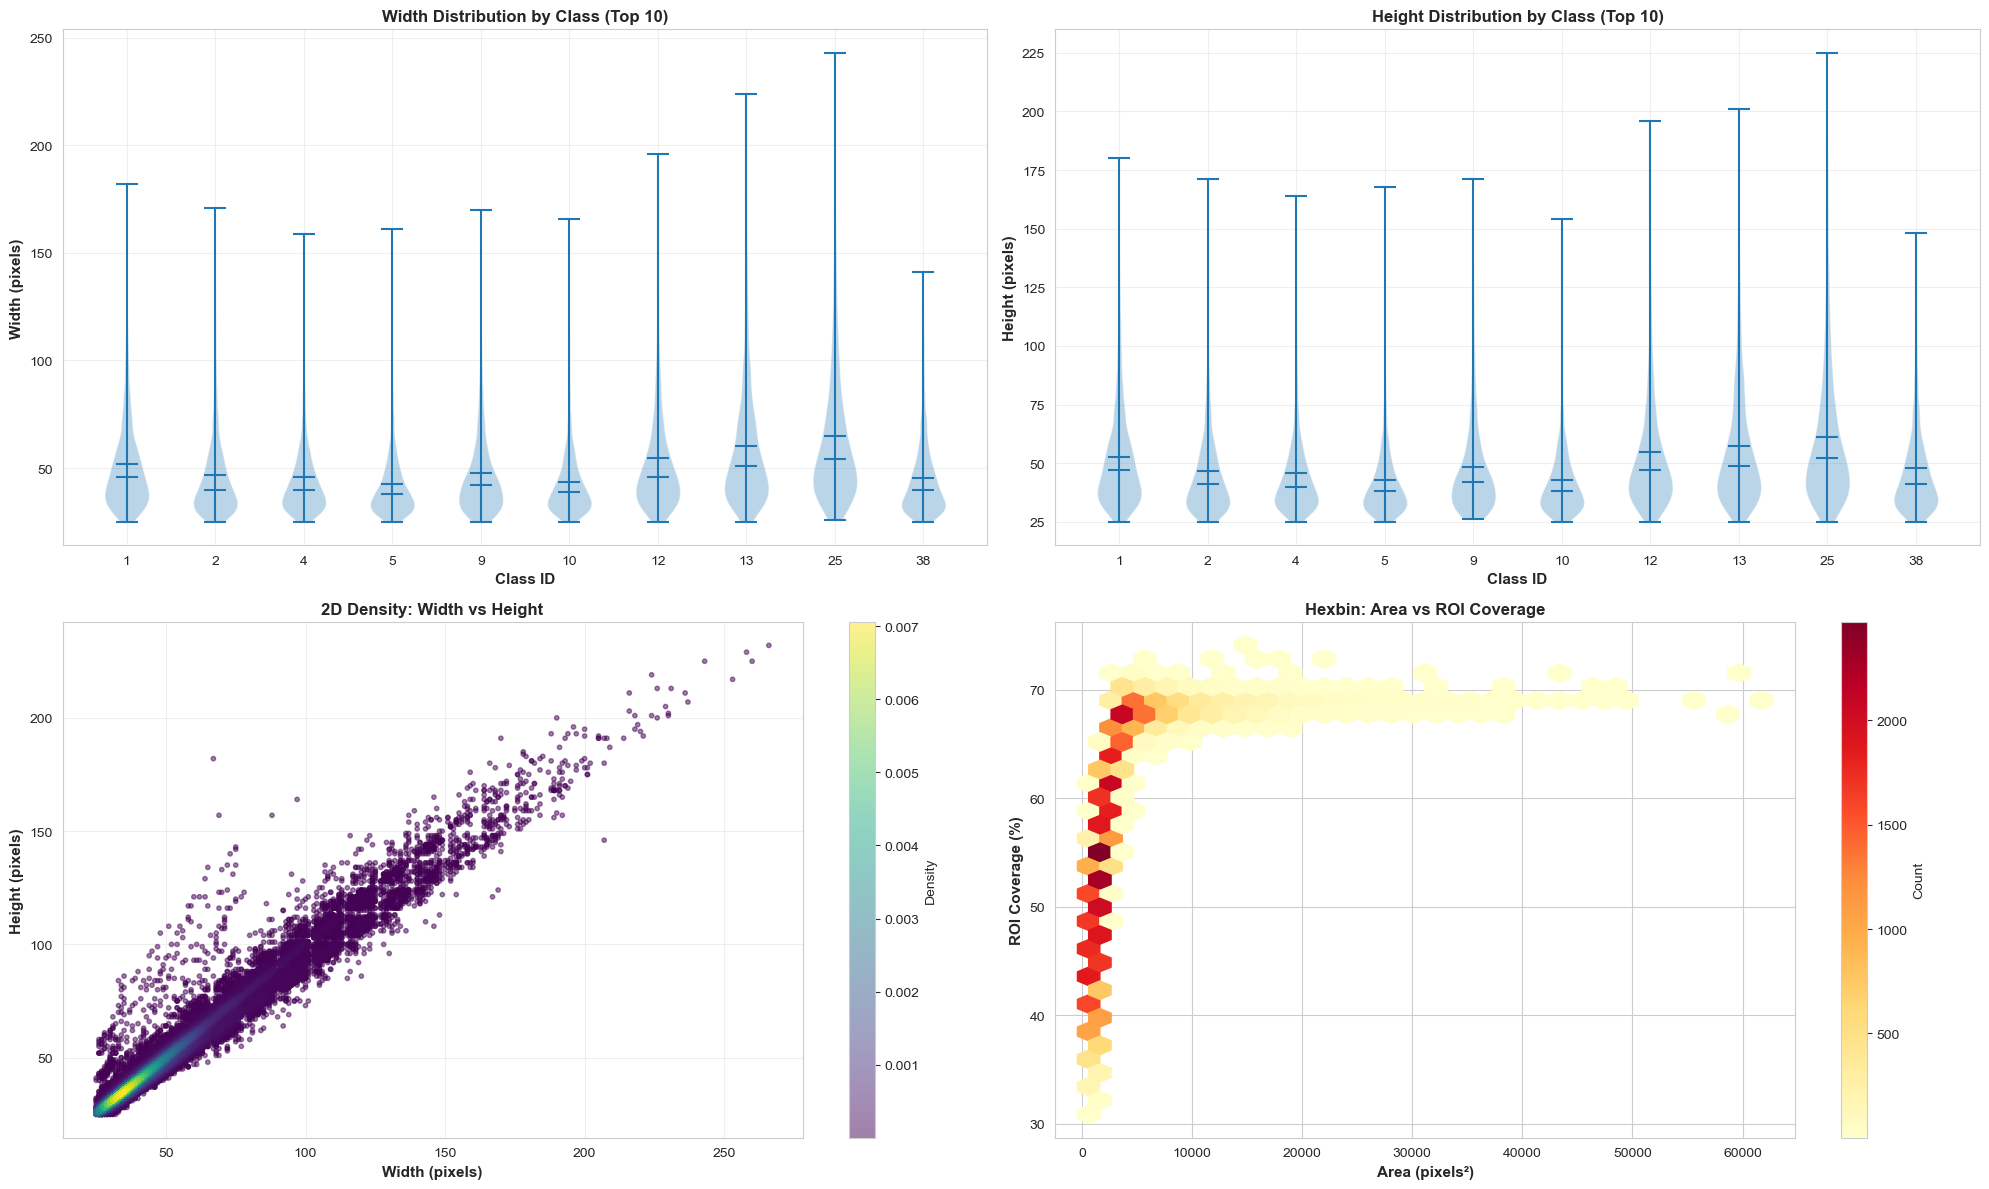

In [11]:
# ============================================================================
# 9. ADVANCED VISUALIZATIONS
# ============================================================================

print("\n" + "="*80)
print("9. ADVANCED VISUALIZATIONS")
print("="*80)

# Violin plots
fig, axes = plt.subplots(2, 2, figsize=(20, 12))

# Sample 10 classes for clearer visualization
sample_classes = sorted(df['ClassId'].value_counts().head(10).index)
df_sample = df[df['ClassId'].isin(sample_classes)]

# Plot 1: Width distribution by class
axes[0, 0].violinplot([df_sample[df_sample['ClassId']==c]['Width'].values 
                       for c in sample_classes], positions=range(len(sample_classes)), 
                       showmeans=True, showmedians=True)
axes[0, 0].set_xlabel('Class ID', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Width (pixels)', fontsize=11, fontweight='bold')
axes[0, 0].set_title('Width Distribution by Class (Top 10)', fontsize=12, fontweight='bold')
axes[0, 0].set_xticks(range(len(sample_classes)))
axes[0, 0].set_xticklabels(sample_classes)
axes[0, 0].grid(alpha=0.3)

# Plot 2: Height distribution by class
axes[0, 1].violinplot([df_sample[df_sample['ClassId']==c]['Height'].values 
                       for c in sample_classes], positions=range(len(sample_classes)),
                       showmeans=True, showmedians=True)
axes[0, 1].set_xlabel('Class ID', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('Height (pixels)', fontsize=11, fontweight='bold')
axes[0, 1].set_title('Height Distribution by Class (Top 10)', fontsize=12, fontweight='bold')
axes[0, 1].set_xticks(range(len(sample_classes)))
axes[0, 1].set_xticklabels(sample_classes)
axes[0, 1].grid(alpha=0.3)

# Plot 3: 2D Density plot - Width vs Height
from scipy.stats import gaussian_kde
x = df['Width'].values
y = df['Height'].values
xy = np.vstack([x, y])
z = gaussian_kde(xy)(xy)
idx = z.argsort()
x, y, z = x[idx], y[idx], z[idx]
scatter = axes[1, 0].scatter(x, y, c=z, s=10, cmap='viridis', alpha=0.5)
axes[1, 0].set_xlabel('Width (pixels)', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Height (pixels)', fontsize=11, fontweight='bold')
axes[1, 0].set_title('2D Density: Width vs Height', fontsize=12, fontweight='bold')
plt.colorbar(scatter, ax=axes[1, 0], label='Density')
axes[1, 0].grid(alpha=0.3)

# Plot 4: Hexbin plot - Area vs ROI Coverage
hexbin = axes[1, 1].hexbin(df['Area'], df['ROI_Coverage'], gridsize=30, cmap='YlOrRd', mincnt=1)
axes[1, 1].set_xlabel('Area (pixels²)', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('ROI Coverage (%)', fontsize=11, fontweight='bold')
axes[1, 1].set_title('Hexbin: Area vs ROI Coverage', fontsize=12, fontweight='bold')
plt.colorbar(hexbin, ax=axes[1, 1], label='Count')

plt.tight_layout()
plt.savefig('07_advanced_visualizations.png', dpi=300, bbox_inches='tight')
print("\n✅ Saved: 07_advanced_visualizations.png")
plt.show()


### 10. DIMENSIONALITY REDUCTION VISUALIZATION (if enough data)


11. DIMENSIONALITY REDUCTION

📊 PCA Analysis:
Number of components: 11

Explained variance ratio (first 5 components):
  PC1: 81.16%
  PC2: 9.55%
  PC3: 7.52%
  PC4: 1.09%
  PC5: 0.42%

Cumulative explained variance:
  First 2 components: 90.71%
  First 3 components: 98.23%
  First 5 components: 99.75%

✅ Saved: 09_pca_analysis.png


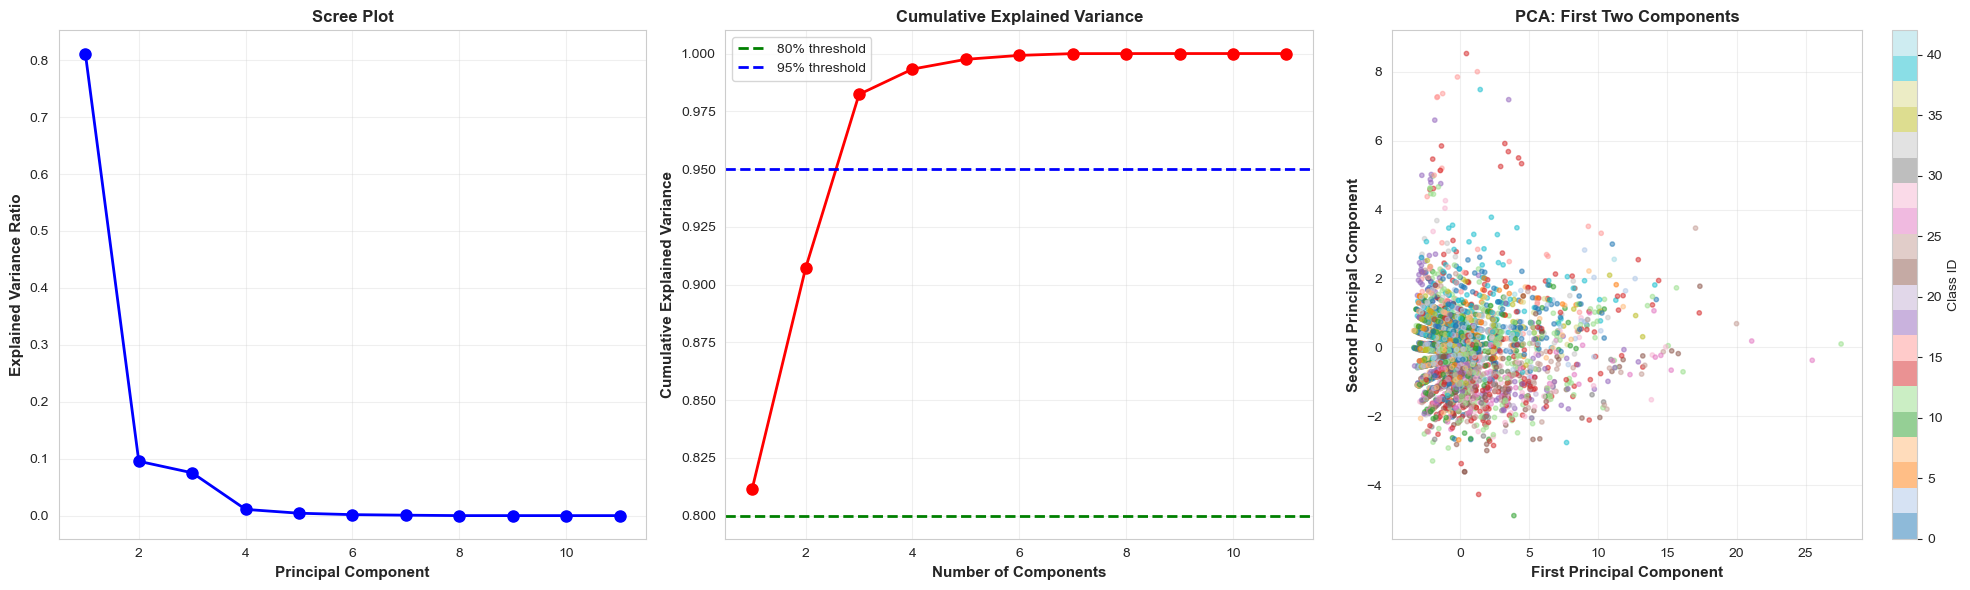

In [12]:
# ============================================================================
# 10. DIMENSIONALITY REDUCTION VISUALIZATION (if enough data)
# ============================================================================

print("\n" + "="*80)
print("11. DIMENSIONALITY REDUCTION")
print("="*80)

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Prepare features for PCA
feature_cols = ['Width', 'Height', 'Roi.X1', 'Roi.Y1', 'Roi.X2', 'Roi.Y2', 
                'AspectRatio', 'Area', 'ROI_Width', 'ROI_Height', 'ROI_Coverage']

X = df[feature_cols].values
y = df['ClassId'].values

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

print("\n📊 PCA Analysis:")
print(f"Number of components: {pca.n_components_}")
print(f"\nExplained variance ratio (first 5 components):")
for i, var in enumerate(pca.explained_variance_ratio_[:5]):
    print(f"  PC{i+1}: {var*100:.2f}%")

cumsum = np.cumsum(pca.explained_variance_ratio_)
print(f"\nCumulative explained variance:")
print(f"  First 2 components: {cumsum[1]*100:.2f}%")
print(f"  First 3 components: {cumsum[2]*100:.2f}%")
print(f"  First 5 components: {cumsum[4]*100:.2f}%")

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Plot 1: Scree plot
axes[0].plot(range(1, len(pca.explained_variance_ratio_)+1), 
            pca.explained_variance_ratio_, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Principal Component', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Explained Variance Ratio', fontsize=11, fontweight='bold')
axes[0].set_title('Scree Plot', fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3)

# Plot 2: Cumulative explained variance
axes[1].plot(range(1, len(cumsum)+1), cumsum, 'ro-', linewidth=2, markersize=8)
axes[1].axhline(0.8, color='green', linestyle='--', linewidth=2, label='80% threshold')
axes[1].axhline(0.95, color='blue', linestyle='--', linewidth=2, label='95% threshold')
axes[1].set_xlabel('Number of Components', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Cumulative Explained Variance', fontsize=11, fontweight='bold')
axes[1].set_title('Cumulative Explained Variance', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

# Plot 3: 2D PCA scatter (sample for visualization)
sample_size = min(5000, len(df))
sample_idx = np.random.choice(len(X_pca), sample_size, replace=False)
scatter = axes[2].scatter(X_pca[sample_idx, 0], X_pca[sample_idx, 1], 
                         c=y[sample_idx], cmap='tab20', alpha=0.5, s=10)
axes[2].set_xlabel('First Principal Component', fontsize=11, fontweight='bold')
axes[2].set_ylabel('Second Principal Component', fontsize=11, fontweight='bold')
axes[2].set_title('PCA: First Two Components', fontsize=12, fontweight='bold')
plt.colorbar(scatter, ax=axes[2], label='Class ID')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('09_pca_analysis.png', dpi=300, bbox_inches='tight')
print("\n✅ Saved: 09_pca_analysis.png")
plt.show()


### 11. DATA QUALITY REPORT

In [13]:
# ============================================================================
# 11. DATA QUALITY REPORT
# ============================================================================

print("\n" + "="*80)
print("12. DATA QUALITY REPORT")
print("="*80)

quality_report = {
    'Total Samples': len(df),
    'Total Classes': df['ClassId'].nunique(),
    'Missing Values': df.isnull().sum().sum(),
    'Duplicate Rows': df.duplicated().sum(),
    'Complete Cases': len(df) - df.isnull().any(axis=1).sum(),
    'Completeness (%)': ((len(df) - df.isnull().any(axis=1).sum()) / len(df) * 100),
}

print("\n📋 Data Quality Metrics:")
for key, value in quality_report.items():
    print(f"  {key}: {value}")

# Check for potential issues
print("\n⚠️  Potential Issues:")
issues = []

# Check class imbalance
max_samples = df['ClassId'].value_counts().max()
min_samples = df['ClassId'].value_counts().min()
imbalance_ratio = max_samples / min_samples
if imbalance_ratio > 10:
    issues.append(f"Severe class imbalance (ratio: {imbalance_ratio:.2f}x)")
elif imbalance_ratio > 5:
    issues.append(f"Moderate class imbalance (ratio: {imbalance_ratio:.2f}x)")

# Check for extreme dimensions
if df['Width'].min() < 20 or df['Height'].min() < 20:
    issues.append(f"Very small images detected (min: {df['Width'].min()}x{df['Height'].min()})")

# Check ROI coverage
low_coverage = (df['ROI_Coverage'] < 50).sum()
if low_coverage > len(df) * 0.1:
    issues.append(f"Low ROI coverage in {low_coverage} images ({low_coverage/len(df)*100:.1f}%)")

if len(issues) == 0:
    print("  ✅ No major issues detected!")
else:
    for i, issue in enumerate(issues, 1):
        print(f"  {i}. {issue}")



12. DATA QUALITY REPORT

📋 Data Quality Metrics:
  Total Samples: 51839
  Total Classes: 43
  Missing Values: 0
  Duplicate Rows: 0
  Complete Cases: 51839
  Completeness (%): 100.0

⚠️  Potential Issues:
  1. Severe class imbalance (ratio: 11.11x)
  2. Low ROI coverage in 16017 images (30.9%)


### 12. SUMMARY STATISTICS TABLE

In [14]:
# ============================================================================
# 12. SUMMARY STATISTICS TABLE
# ============================================================================

print("\n" + "="*80)
print("13. COMPREHENSIVE SUMMARY TABLE")
print("="*80)

summary_data = {
    'Metric': [
        'Total Images',
        'Total Classes',
        'Avg Width',
        'Avg Height',
        'Avg Area',
        'Avg Aspect Ratio',
        'Min Width',
        'Max Width',
        'Min Height',
        'Max Height',
        'Avg ROI Coverage (%)',
        'Most Common Class',
        'Least Common Class',
        'Class Imbalance Ratio'
    ],
    'Value': [
        len(df),
        df['ClassId'].nunique(),
        f"{df['Width'].mean():.2f} px",
        f"{df['Height'].mean():.2f} px",
        f"{df['Area'].mean():.2f} px²",
        f"{df['AspectRatio'].mean():.2f}",
        f"{df['Width'].min()} px",
        f"{df['Width'].max()} px",
        f"{df['Height'].min()} px",
        f"{df['Height'].max()} px",
        f"{df['ROI_Coverage'].mean():.2f}%",
        f"Class {df['ClassId'].value_counts().idxmax()} ({df['ClassId'].value_counts().max()} samples)",
        f"Class {df['ClassId'].value_counts().idxmin()} ({df['ClassId'].value_counts().min()} samples)",
        f"{df['ClassId'].value_counts().max() / df['ClassId'].value_counts().min():.2f}x"
    ]
}

summary_df = pd.DataFrame(summary_data)
print("\n" + summary_df.to_string(index=False))

# Save summary
summary_df.to_csv('dataset_summary.csv', index=False)
print("\n✅ Saved: dataset_summary.csv")



13. COMPREHENSIVE SUMMARY TABLE

               Metric                  Value
         Total Images                  51839
        Total Classes                     43
            Avg Width               50.76 px
           Avg Height               50.34 px
             Avg Area            3113.53 px²
     Avg Aspect Ratio                   1.01
            Min Width                  25 px
            Max Width                 266 px
           Min Height                  25 px
           Max Height                 232 px
 Avg ROI Coverage (%)                 56.13%
    Most Common Class Class 2 (3000 samples)
   Least Common Class Class 37 (270 samples)
Class Imbalance Ratio                 11.11x

✅ Saved: dataset_summary.csv


### 13. EXPORT PROCESSED DATA <a id='data-cleaning'>

In [17]:
# ============================================================================
# 13. EXPORT PROCESSED DATA
# ============================================================================

print("\n" + "="*80)
print("13. EXPORTING PROCESSED DATA")
print("="*80)

# Save enhanced dataframe with calculated features
output_cols = ['Path', 'ClassId', 'Width', 'Height', 'Roi.X1', 'Roi.Y1', 
               'Roi.X2', 'Roi.Y2', 'AspectRatio', 'Area', 'ROI_Width', 
               'ROI_Height', 'ROI_Coverage']

df_export = df[output_cols].copy()
df_export.to_csv('enhanced_dataset.csv', index=False)


13. EXPORTING PROCESSED DATA


In [ ]:
def crop_to_roi(image_path, x1, y1, x2, y2):
    """
    Crop image to the region of interest defined by bounding box coordinates.
    
    Args:
        image_path: Path to the image file
        x1, y1: Top-left corner coordinates
        x2, y2: Bottom-right corner coordinates
    
    Returns:
        Cropped image as numpy array
    """
    img = cv2.imread(image_path)
    if img is None:
        return None
    
    # Crop the image to ROI
    cropped = img[y1:y2, x1:x2]
    return cropped

def preprocess_dataset(df, dataset_path, output_path, target_size=(32, 32)):
    """
    Preprocess all images in the dataset by cropping to ROI.
    
    Args:
        df: DataFrame containing image info and bounding boxes
        dataset_path: Path to the dataset folder
        output_path: Path to save cropped images
        target_size: Resize cropped images to this size (width, height)
    """
    os.makedirs(output_path, exist_ok=True)
    
    cropped_images = []
    labels = []
    
    for idx, row in tqdm(df.iterrows(), total=len(df), desc="Processing images"):
        # Adjust these column names based on your CSV structure
        # Common names: 'Path', 'Roi.X1', 'Roi.Y1', 'Roi.X2', 'Roi.Y2', 'ClassId'
        img_path = os.path.join(dataset_path, row['Path'])
        
        # Get bounding box coordinates
        x1 = int(row['Roi.X1'])
        y1 = int(row['Roi.Y1'])
        x2 = int(row['Roi.X2'])
        y2 = int(row['Roi.Y2'])
        class_id = row['ClassId']
        
        # Crop the image
        cropped = crop_to_roi(img_path, x1, y1, x2, y2)
        
        if cropped is not None and cropped.size > 0:
            # Resize to standard size
            cropped_resized = cv2.resize(cropped, target_size, interpolation=cv2.INTER_AREA)
            
            cropped_images.append(cropped_resized)
            labels.append(class_id)
            
            # Optionally save individual cropped images
            # output_file = os.path.join(output_path, f"cropped_{idx}.png")
            # cv2.imwrite(output_file, cropped_resized)
    
    return np.array(cropped_images), np.array(labels)

# Load the dataset
df = pd.read_csv(os.path.join(DF_PATH, 'Test.csv'))

print("DataFrame columns:", df.columns.tolist())
print("\nFirst few rows:")
print(df.head())

# Preprocess and crop all images
output_path = './gtrsb_dataset/cropped_test'
cropped_images, labels = preprocess_dataset(
    df, 
    DF_PATH, 
    output_path,
    target_size=(48, 48)  # Adjust size as needed
)

print(f"\nProcessed {len(cropped_images)} images")
#print(f"Image shape: {cropped_images[0].shape}")
print(f"Labels shape: {labels.shape}")

# Save preprocessed data
np.save(os.path.join(output_path, 'cropped_images.npy'), cropped_images)
np.save(os.path.join(output_path, 'labels.npy'), labels)
print(f"\nSaved preprocessed data to {output_path}")

DataFrame columns: ['Width', 'Height', 'Roi.X1', 'Roi.Y1', 'Roi.X2', 'Roi.Y2', 'ClassId', 'Path']

First few rows:
   Width  Height  Roi.X1  Roi.Y1  Roi.X2  Roi.Y2  ClassId            Path
0     53      54       6       5      48      49       16  Test/00000.png
1     42      45       5       5      36      40        1  Test/00001.png
2     48      52       6       6      43      47       38  Test/00002.png
3     27      29       5       5      22      24       33  Test/00003.png
4     60      57       5       5      55      52       11  Test/00004.png


Processing images:   0%|          | 0/12630 [00:00<?, ?it/s]

Processing images: 100%|██████████| 12630/12630 [00:08<00:00, 1434.55it/s]



Processed 12630 images
Labels shape: (12630,)

Saved preprocessed data to ./gtrsb_dataset/cropped_test


Generating before/after comparison...



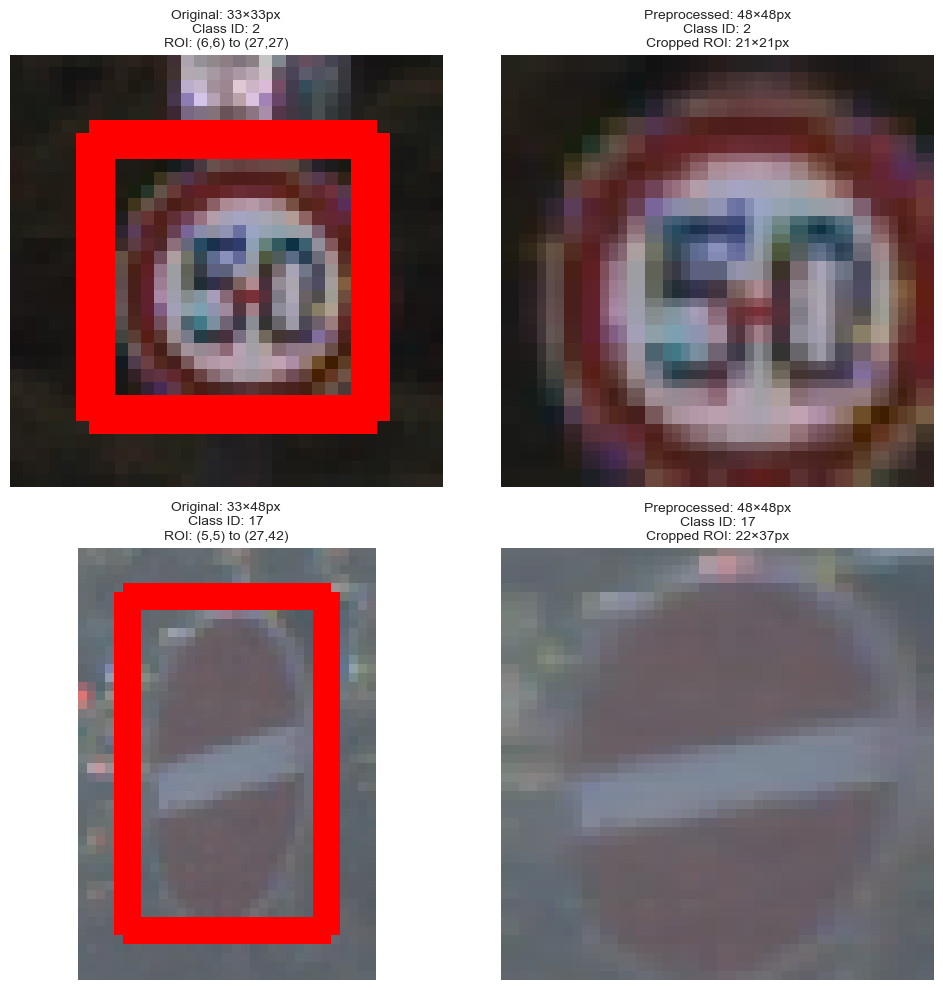

Comparison saved to: ./gtrsb_dataset/preprocessing_comparison.png


In [ ]:
def visualize_preprocessing(df, dataset_path, num_samples=2, target_size=(48, 48)):
    """
    Visualize before and after preprocessing for comparison.
    
    Args:
        df: DataFrame with image info
        dataset_path: Root path of dataset
        num_samples: Number of image pairs to show
        target_size: Target size for cropped images
    """
    fig, axes = plt.subplots(num_samples, 2, figsize=(10, 5*num_samples))
    
    # Handle case where num_samples = 1
    if num_samples == 1:
        axes = axes.reshape(1, -1)
    
    for i in range(num_samples):
        # Get random sample
        idx = np.random.randint(0, len(df))
        row = df.iloc[idx]
        
        # Load original image
        img_path = os.path.join(dataset_path, row['Path'])
        original = cv2.imread(img_path)
        original_rgb = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
        
        # Get bounding box
        x1, y1 = int(row['Roi.X1']), int(row['Roi.Y1'])
        x2, y2 = int(row['Roi.X2']), int(row['Roi.Y2'])
        class_id = row['ClassId']
        
        # Create copy with bounding box drawn
        original_with_box = original_rgb.copy()
        cv2.rectangle(original_with_box, (x1, y1), (x2, y2), (255, 0, 0), 2)
        
        # Crop and resize
        cropped = original[y1:y2, x1:x2]
        cropped_rgb = cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB)
        cropped_resized = cv2.resize(cropped_rgb, target_size, interpolation=cv2.INTER_AREA)
        
        # Plot original with bounding box
        axes[i, 0].imshow(original_with_box)
        axes[i, 0].set_title(f'Original: {original_rgb.shape[1]}×{original_rgb.shape[0]}px\n'
                            f'Class ID: {class_id}\n'
                            f'ROI: ({x1},{y1}) to ({x2},{y2})', fontsize=10)
        axes[i, 0].axis('off')
        
        # Plot cropped and resized
        axes[i, 1].imshow(cropped_resized)
        axes[i, 1].set_title(f'Preprocessed: {target_size[0]}×{target_size[1]}px\n'
                            f'Class ID: {class_id}\n'
                            f'Cropped ROI: {x2-x1}×{y2-y1}px', fontsize=10)
        axes[i, 1].axis('off')
    
    plt.tight_layout()
    plt.savefig('./gtrsb_dataset/preprocessing_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Comparison saved to: ./gtrsb_dataset/preprocessing_comparison.png")

# Visualize the preprocessing

df = pd.read_csv(os.path.join(DF_PATH, 'Test.csv'))

print("Generating before/after comparison...\n")
visualize_preprocessing(df, DF_PATH, num_samples=2, target_size=(48, 48))



DATA AUGMENTATION FOR CLASS BALANCING

Loaded 12630 preprocessed images

Generating augmentation examples...


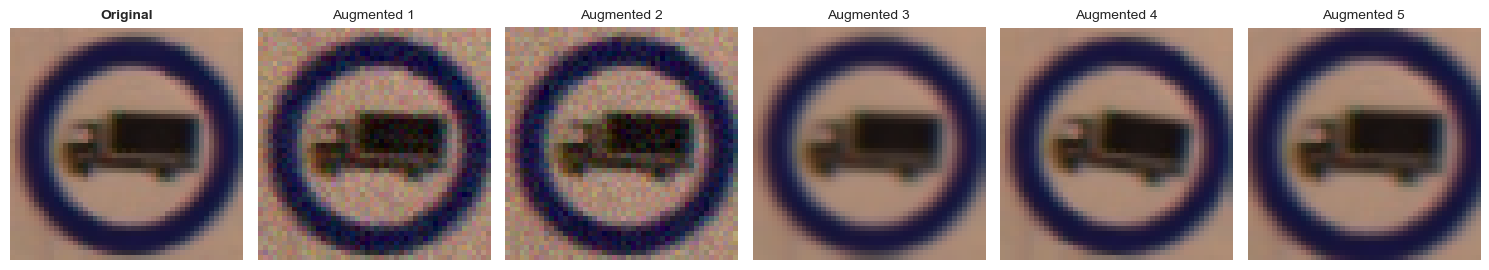

Augmentation examples saved to: ./gtrsb_dataset/augmentation_examples.png

Balancing dataset with augmentation...
Original class distribution:
Min samples: 60
Max samples: 750
Mean samples: 293.7
Median samples: 180.0

Target samples per class: 600



Balancing classes: 100%|██████████| 43/43 [00:00<00:00, 46.01it/s]



BALANCING COMPLETE
Original dataset size: 12630
Balanced dataset size: 26520
Images added: 13890

Generating distribution comparison...


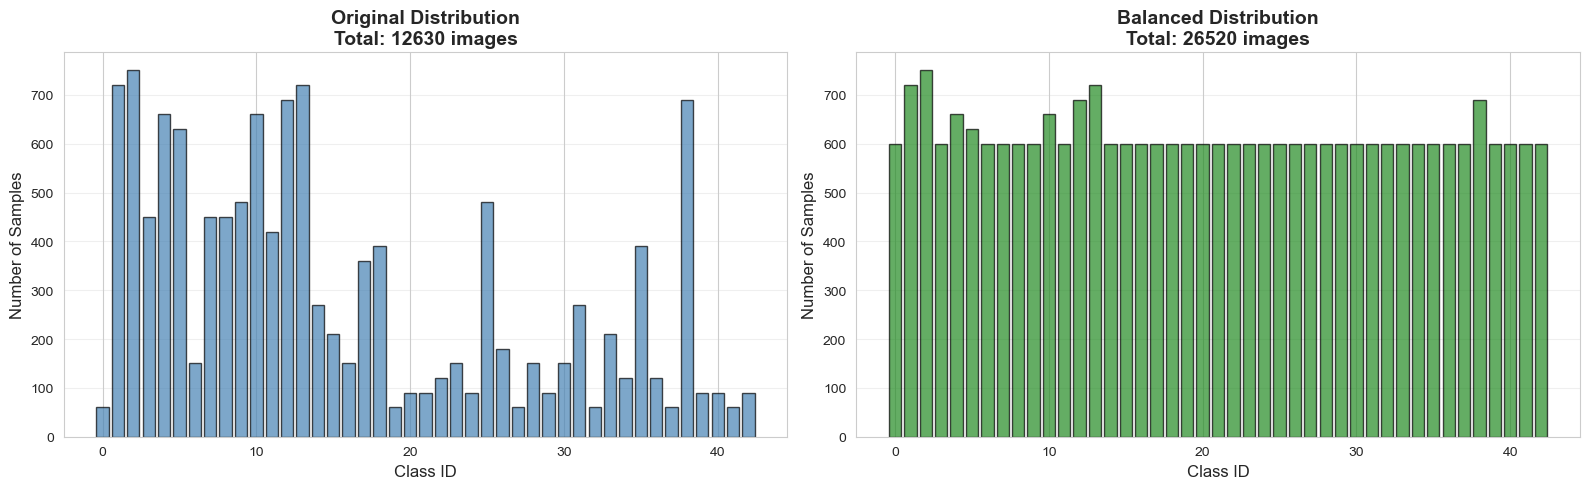


Distribution comparison saved to: ./gtrsb_dataset/distribution_comparison.png

Balanced dataset saved to: ./gtrsb_dataset/balanced_test

Final statistics:
Number of classes: 43
Min samples per class: 600
Max samples per class: 750
Mean samples per class: 616.7
Std samples per class: 38.4


In [ ]:
def augment_image(image):
    """
    Apply random augmentation to an image.
    Returns augmented image.
    """
    # Randomly choose augmentation technique
    aug_type = np.random.randint(0, 5)
    
    if aug_type == 0:
        # Rotation (±15 degrees)
        angle = np.random.uniform(-15, 15)
        h, w = image.shape[:2]
        M = cv2.getRotationMatrix2D((w/2, h/2), angle, 1.0)
        augmented = cv2.warpAffine(image, M, (w, h), borderMode=cv2.BORDER_REPLICATE)
        
    elif aug_type == 1:
        # Brightness adjustment
        factor = np.random.uniform(0.7, 1.3)
        augmented = np.clip(image * factor, 0, 255).astype(np.uint8)
        
    elif aug_type == 2:
        # Gaussian noise
        noise = np.random.normal(0, 10, image.shape)
        augmented = np.clip(image + noise, 0, 255).astype(np.uint8)
        
    #elif aug_type == 4:
    #    # Horizontal flip (careful with traffic signs - some are symmetric)
    #    augmented = cv2.flip(image, 1)
        
    elif aug_type == 3:
        # Slight zoom (crop and resize)
        h, w = image.shape[:2]
        crop_percent = np.random.uniform(0.85, 0.95)
        new_h, new_w = int(h * crop_percent), int(w * crop_percent)
        y1 = (h - new_h) // 2
        x1 = (w - new_w) // 2
        cropped = image[y1:y1+new_h, x1:x1+new_w]
        augmented = cv2.resize(cropped, (w, h))
        
    else:
        # Gaussian blur
        augmented = cv2.GaussianBlur(image, (3, 3), 0)
    
    return augmented

def balance_dataset_with_augmentation(images, labels, target_samples_per_class=None, max_samples_per_class=None):
    """
    Balance dataset by augmenting underrepresented classes.
    
    Args:
        images: numpy array of images
        labels: numpy array of labels
        target_samples_per_class: target number of samples per class (default: median)
        max_samples_per_class: maximum samples per class to avoid over-augmenting
    
    Returns:
        balanced_images, balanced_labels
    """
    unique_classes = np.unique(labels)
    class_counts = {cls: np.sum(labels == cls) for cls in unique_classes}
    
    print("Original class distribution:")
    print(f"Min samples: {min(class_counts.values())}")
    print(f"Max samples: {max(class_counts.values())}")
    print(f"Mean samples: {np.mean(list(class_counts.values())):.1f}")
    print(f"Median samples: {np.median(list(class_counts.values())):.1f}\n")
    
    # Set target if not provided
    if target_samples_per_class is None:
        target_samples_per_class = int(np.median(list(class_counts.values())))
    
    if max_samples_per_class is None:
        max_samples_per_class = max(class_counts.values())
    
    # Cap target at max
    target_samples_per_class = min(target_samples_per_class, max_samples_per_class)
    
    print(f"Target samples per class: {target_samples_per_class}\n")
    
    balanced_images = []
    balanced_labels = []
    
    for cls in tqdm(unique_classes, desc="Balancing classes"):
        # Get all images for this class
        class_mask = labels == cls
        class_images = images[class_mask]
        current_count = len(class_images)
        
        # Add all original images
        balanced_images.extend(class_images)
        balanced_labels.extend([cls] * current_count)
        
        # Augment if needed
        if current_count < target_samples_per_class:
            needed = target_samples_per_class - current_count
            
            # Generate augmented images
            for _ in range(needed):
                # Pick random image from this class
                idx = np.random.randint(0, current_count)
                original = class_images[idx]
                
                # Augment it
                augmented = augment_image(original)
                
                balanced_images.append(augmented)
                balanced_labels.append(cls)
    
    return np.array(balanced_images), np.array(balanced_labels)

def plot_class_distribution_comparison(original_labels, balanced_labels, output_path):
    """
    Plot before and after class distribution.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    
    # Original distribution
    unique_orig, counts_orig = np.unique(original_labels, return_counts=True)
    ax1.bar(unique_orig, counts_orig, color='steelblue', edgecolor='black', alpha=0.7)
    ax1.set_xlabel('Class ID', fontsize=12)
    ax1.set_ylabel('Number of Samples', fontsize=12)
    ax1.set_title(f'Original Distribution\nTotal: {len(original_labels)} images', fontsize=14, fontweight='bold')
    ax1.grid(axis='y', alpha=0.3)
    
    # Balanced distribution
    unique_bal, counts_bal = np.unique(balanced_labels, return_counts=True)
    ax2.bar(unique_bal, counts_bal, color='forestgreen', edgecolor='black', alpha=0.7)
    ax2.set_xlabel('Class ID', fontsize=12)
    ax2.set_ylabel('Number of Samples', fontsize=12)
    ax2.set_title(f'Balanced Distribution\nTotal: {len(balanced_labels)} images', fontsize=14, fontweight='bold')
    ax2.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(output_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"\nDistribution comparison saved to: {output_path}")

def visualize_augmentations(image, num_augmentations=5):
    """
    Show original image and several augmented versions.
    """
    fig, axes = plt.subplots(1, num_augmentations + 1, figsize=(15, 3))
    
    # Original
    axes[0].imshow(image)
    axes[0].set_title('Original', fontsize=10, fontweight='bold')
    axes[0].axis('off')
    
    # Augmented versions
    for i in range(num_augmentations):
        augmented = augment_image(image)
        axes[i+1].imshow(augmented)
        axes[i+1].set_title(f'Augmented {i+1}', fontsize=10)
        axes[i+1].axis('off')
    
    plt.tight_layout()
    plt.savefig('./gtrsb_dataset/augmentation_examples.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Augmentation examples saved to: ./gtrsb_dataset/augmentation_examples.png")

# Main execution
print("="*60)
print("DATA AUGMENTATION FOR CLASS BALANCING")
print("="*60)

# Load preprocessed data
output_path = './gtrsb_dataset/cropped_test'
cropped_images = np.load(os.path.join(output_path, 'cropped_images.npy'))
labels = np.load(os.path.join(output_path, 'labels.npy'))

print(f"\nLoaded {len(cropped_images)} preprocessed images")

# Show example of augmentations
print("\nGenerating augmentation examples...")
sample_image = cropped_images[0]
visualize_augmentations(sample_image, num_augmentations=5)

# Balance the dataset
print("\nBalancing dataset with augmentation...")
balanced_images, balanced_labels = balance_dataset_with_augmentation(
    cropped_images, 
    labels,
    target_samples_per_class=600,  # Adjust this value as needed
    max_samples_per_class=750      # Cap to avoid making majority classes too large
)

print("\n" + "="*60)
print("BALANCING COMPLETE")
print("="*60)
print(f"Original dataset size: {len(cropped_images)}")
print(f"Balanced dataset size: {len(balanced_images)}")
print(f"Images added: {len(balanced_images) - len(cropped_images)}")

# Plot comparison
print("\nGenerating distribution comparison...")
plot_class_distribution_comparison(
    labels, 
    balanced_labels,
    './gtrsb_dataset/distribution_comparison.png'
)

# Save balanced dataset
balanced_output_path = './gtrsb_dataset/balanced_test'
os.makedirs(balanced_output_path, exist_ok=True)
np.save(os.path.join(balanced_output_path, 'balanced_images.npy'), balanced_images)
np.save(os.path.join(balanced_output_path, 'balanced_labels.npy'), balanced_labels)

print(f"\n{'='*60}")
print(f"Balanced dataset saved to: {balanced_output_path}")
print(f"{'='*60}")

# Final statistics
unique_classes, counts = np.unique(balanced_labels, return_counts=True)
print(f"\nFinal statistics:")
print(f"Number of classes: {len(unique_classes)}")
print(f"Min samples per class: {counts.min()}")
print(f"Max samples per class: {counts.max()}")
print(f"Mean samples per class: {counts.mean():.1f}")
print(f"Std samples per class: {counts.std():.1f}")

### Color Histograms 

<a id ="feature-engineering"> </a>

In [27]:
def extract_histograms_from_dataset(df, max_samples=None):
    """
    Extract color histograms for all ROIs in your dataset
    """
    features_list = []
    failed_paths = []
    
    # Limit samples ias df.head(x)
    if max_samples:
        df = df.head(max_samples)
    
    for idx, row in df.iterrows():
        try:
            img_path = Path(DF_PATH) / row['Path']
            
            if not img_path.exists():
                print(f"Image not found: {img_path}")
                failed_paths.append(row['Path'])
                continue
            
            # Read image
            image = cv2.imread(str(img_path))
            if image is None:
                print(f"Could not read image: {img_path}")
                failed_paths.append(row['Path'])
                continue
            
            # Extract ROI using your bounding box coordinates
            # Assuming Roi.X1, Roi.Y1, Roi.X2, Roi.Y2 are the coordinates
            x1, y1, x2, y2 = row['Roi.X1'], row['Roi.Y1'], row['Roi.X2'], row['Roi.Y2']
            
            # Ensure coordinates are within image bounds
            h, w = image.shape[:2]
            x1, y1 = max(0, x1), max(0, y1)
            x2, y2 = min(w, x2), min(h, y2)
            
            if x2 <= x1 or y2 <= y1:
                print(f"Invalid ROI coordinates in row {idx}")
                continue
            
            
            roi = image[y1:y2, x1:x2]
            
            if roi.size == 0:
                print(f"Empty ROI in row {idx}")
                continue
        
            histograms = calculate_comprehensive_histograms(roi)
            
            # feature row
            feature_row = {
                'index': idx,
                'ClassId': row['ClassId'],
                'SignId': row['SignId'],
                'ColorId': row['ColorId'],
                'ShapeId': row['ShapeId'],
                'Path': row['Path']
            }
            
            
            feature_row.update(histograms)
            features_list.append(feature_row)
            
            if idx % 1000 == 0:
                print(f"Processed {idx} samples...")
                
        except Exception as e:
            print(f"Error processing row {idx}: {e}")
            failed_paths.append(row['Path'])
    
    print(f"Successfully processed {len(features_list)} samples")
    print(f"Failed to process {len(failed_paths)} samples")
    
    return pd.DataFrame(features_list), failed_paths

def calculate_comprehensive_histograms(roi, bins=32):
    """
    Calculate comprehensive color histograms from ROI
    """
    # Convert to different color spaces
    hsv = cv2.cvtColor(roi, cv2.COLOR_BGR2HSV)
    lab = cv2.cvtColor(roi, cv2.COLOR_BGR2LAB)
    
    histograms = {}
    
    # BGR histograms
    for i, color in enumerate(['B', 'G', 'R']):
        hist = cv2.calcHist([roi], [i], None, [bins], [0, 256])
        histograms[f'hist_bgr_{color}'] = cv2.normalize(hist, hist).flatten()
    
    # HSV histograms
    for i, color in enumerate(['H', 'S', 'V']):
        hist = cv2.calcHist([hsv], [i], None, [bins], [0, 256])
        histograms[f'hist_hsv_{color}'] = cv2.normalize(hist, hist).flatten()
    
    # LAB histograms
    for i, color in enumerate(['L', 'A', 'B']):
        hist = cv2.calcHist([lab], [i], None, [bins], [0, 256])
        histograms[f'hist_lab_{color}'] = cv2.normalize(hist, hist).flatten()
    
    # Combine
    all_features = []
    for key in sorted(histograms.keys()):
        all_features.extend(histograms[key])
    
    histograms['color_feature_vector'] = np.array(all_features)
    
    return histograms


### Histograms of Orientend Gradients

In [ ]:
def create_feature_sets_with_hog(train_df_color, test_df_color, train_df, test_df):
    """
    Combine color histograms, ShapeId, and HOG features.
    """
    X_color_train = np.stack(train_df_color['color_feature_vector'].values)
    X_color_test = np.stack(test_df_color['color_feature_vector'].values)
    
    # shape ID removed from training
    #shape_train = pd.get_dummies(train_df_color['ShapeId'], prefix='Shape')
    #shape_test = pd.get_dummies(test_df_color['ShapeId'], prefix='Shape')
    #shape_train, shape_test = shape_train.align(shape_test, join='outer', axis=1, fill_value=0)
    
    X_hog_train, X_hog_test = [], []
    for df, output_list in zip([train_df, test_df], [X_hog_train, X_hog_test]):
        for idx, row in df.iterrows():
            img_path = Path(DF_PATH) / row['Path']
            img = cv2.imread(str(img_path))
            # zeroes if no image
            if img is None:
                output_list.append(np.zeros(324))  
                continue
            x1, y1, x2, y2 = row['Roi.X1'], row['Roi.Y1'], row['Roi.X2'], row['Roi.Y2']
            roi = img[y1:y2, x1:x2]
            # Resize ROI to fixed size
            roi_resized = cv2.resize(roi, (64, 64))
            hog_feat = extract_hog_features(roi_resized)
            output_list.append(hog_feat)
    
    X_hog_train = np.array(X_hog_train)
    X_hog_test = np.array(X_hog_test)
    
    # stacking features separately
    X_train = np.hstack([X_color_train, X_hog_train])
    X_test = np.hstack([X_color_test, X_hog_test])
    
    y_train = train_df['ClassId'].values
    y_test = test_df['ClassId'].values
    
    return X_train, X_test, y_train, y_test

### Hu Moments

In [31]:
def extract_shape_features(image):
    """
    Extract shape features using Hu Moments and basic shape descriptors.
    
    Hu Moments are invariant to translation, rotation, and scale.
    Perfect for capturing the overall shape of traffic signs.
    
    Returns:
        Shape features (7 Hu moments + additional shape descriptors)
    """
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    
    # Apply binary threshold to get shape silhouette
    _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
    # Calculate image moments
    moments = cv2.moments(binary)
    
    # Calculate Hu Moments (7 features)
    hu_moments = cv2.HuMoments(moments).flatten()
    
    # Log transform for better scale (Hu moments can be very small/large)
    hu_moments = -np.sign(hu_moments) * np.log10(np.abs(hu_moments) + 1e-10)
    
    # Additional shape descriptors
    additional_features = []
    
    # Contour-based features
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    if len(contours) > 0:
        # Get the largest contour (assumed to be the traffic sign)
        largest_contour = max(contours, key=cv2.contourArea)
        
        # Area and perimeter
        area = cv2.contourArea(largest_contour)
        perimeter = cv2.arcLength(largest_contour, True)
        
        # Circularity (how circular is the shape)
        circularity = 4 * np.pi * area / (perimeter ** 2 + 1e-10)
        
        # Aspect ratio from bounding rectangle
        if len(largest_contour) >= 5:
            ellipse = cv2.fitEllipse(largest_contour)
            major_axis = max(ellipse[1])
            minor_axis = min(ellipse[1])
            aspect_ratio = major_axis / (minor_axis + 1e-10)
        else:
            aspect_ratio = 1.0
        
        # Extent (ratio of contour area to bounding box area)
        x, y, w, h = cv2.boundingRect(largest_contour)
        rect_area = w * h
        extent = area / (rect_area + 1e-10)
        
        # Solidity (ratio of contour area to convex hull area)
        hull = cv2.convexHull(largest_contour)
        hull_area = cv2.contourArea(hull)
        solidity = area / (hull_area + 1e-10)
        
        additional_features = [
            area / (gray.shape[0] * gray.shape[1]),  # Normalized area
            perimeter / (2 * (gray.shape[0] + gray.shape[1])),  # Normalized perimeter
            circularity,
            aspect_ratio,
            extent,
            solidity
        ]
    else:
        # If no contours found, use default values
        additional_features = [0.0, 0.0, 0.0, 1.0, 0.0, 0.0]
    
    # Combine all shape features
    shape_features = np.concatenate([hu_moments, additional_features])
    
    return shape_features

def extract_all_shape_features(images, labels):
    """
    Extract shape features from all images.
    
    Args:
        images: Array of images
        labels: Array of labels
    
    Returns:
        DataFrame with shape features and labels
    """
    print(f"Extracting shape features from {len(images)} images...")
    print("Method: Hu Moments + Shape Descriptors")
    print("Features: 7 Hu moments + 6 shape descriptors = 13 total\n")
    
    all_features = []
    
    for img in tqdm(images, desc="Processing"):
        features = extract_shape_features(img)
        all_features.append(features)
    
    # Convert to numpy array
    feature_matrix = np.array(all_features)
    
    # Generate column names
    column_names = [
        'hu_moment_1', 'hu_moment_2', 'hu_moment_3', 'hu_moment_4',
        'hu_moment_5', 'hu_moment_6', 'hu_moment_7',
        'normalized_area', 'normalized_perimeter', 'circularity',
        'aspect_ratio', 'extent', 'solidity'
    ]
    
    # Create DataFrame
    df = pd.DataFrame(feature_matrix, columns=column_names)
    df['label'] = labels
    
    print(f"\n✓ Feature extraction complete!")
    print(f"DataFrame shape: {df.shape}")
    print(f"Total shape features: {len(column_names)}")
    
    return df

# Extract shape features
shape_features_df = extract_all_shape_features(cropped_images, labels)

# Display results
print("\nFirst few rows:")
print(shape_features_df.head())

print("\nBasic statistics:")
print(shape_features_df.describe())

print("\nFeature descriptions:")
print("  • Hu moments (1-7): Rotation, scale, translation invariant shape descriptors")
print("  • Normalized area: Area relative to image size")
print("  • Normalized perimeter: Perimeter relative to image size")
print("  • Circularity: How circular the shape is (1.0 = perfect circle)")
print("  • Aspect ratio: Ratio of major to minor axis")
print("  • Extent: Ratio of shape area to bounding box area")
print("  • Solidity: Ratio of shape area to convex hull area")

# Save to CSV
output_csv = './gtrsb_dataset/balanced_test/shape_features.csv'
shape_features_df.to_csv(output_csv, index=False)
print(f"\n✓ Saved to: {output_csv}")

Extracting shape features from 12630 images...
Method: Hu Moments + Shape Descriptors
Features: 7 Hu moments + 6 shape descriptors = 13 total



Processing: 100%|██████████| 12630/12630 [00:01<00:00, 10429.05it/s]



✓ Feature extraction complete!
DataFrame shape: (12630, 14)
Total shape features: 13

First few rows:
   hu_moment_1  hu_moment_2  hu_moment_3  hu_moment_4  hu_moment_5  \
0     2.854011     8.392283     9.995393     9.976297        -10.0   
1     3.009683     7.884087     9.977271     9.978869        -10.0   
2     2.682292     6.424212     9.810703     9.571660         10.0   
3     2.760261     6.890955     9.790649     9.743920         10.0   
4     2.798261     7.067768     8.592597     9.689250         10.0   

   hu_moment_6  hu_moment_7  normalized_area  normalized_perimeter  \
0    -9.999999         10.0         0.357856              0.564197   
1     9.999999        -10.0         0.423394              0.616281   
2    -9.999696        -10.0         0.110677              0.546415   
3     9.999949         10.0         0.117839              0.627744   
4     9.999875        -10.0         0.216146              0.548202   

   circularity  aspect_ratio    extent  solidity  label

### Linear Binary Patterns Features

In [ ]:
def extract_lbp_features(image, radius=2, n_points=None, method='uniform'):
    """
    Extract Local Binary Pattern (LBP) features for texture analysis.
    
    LBP is excellent for capturing local texture patterns like:
    - Arrows on signs
    - Numbers and text
    - Directional patterns
    - Surface texture details
    
    Args:
        radius: Radius of circle (default: 2)
        n_points: Number of points on circle (default: 8*radius)
        method: 'uniform' for rotation-invariant uniform patterns
    
    Returns:
        LBP histogram features
    """
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    
    # Set number of points if not specified
    if n_points is None:
        n_points = 8 * radius
    
    # Compute LBP
    lbp = local_binary_pattern(gray, n_points, radius, method=method)
    
    # Calculate histogram
    if method == 'uniform':
        # Uniform patterns have n_points + 2 bins
        n_bins = n_points + 2
    else:
        # Non-uniform patterns have 2^n_points bins
        n_bins = int(lbp.max() + 1)
    
    hist, _ = np.histogram(lbp.ravel(), bins=n_bins, range=(0, n_bins))
    
    # Normalize histogram
    hist = hist.astype(float) / (hist.sum() + 1e-10)
    
    return hist

def extract_all_texture_features(images, labels, radius=2):
    """
    Extract LBP texture features from all images.
    
    Args:
        images: Array of images
        labels: Array of labels
        radius: LBP radius (1=small details, 2=medium, 3=larger patterns)
    
    Returns:
        DataFrame with LBP texture features and labels
    """
    n_points = 8 * radius
    n_bins = n_points + 2  # For uniform LBP
    
    print(f"Extracting texture features from {len(images)} images...")
    print(f"Method: Local Binary Patterns (LBP)")
    print(f"Parameters:")
    print(f"  - Radius: {radius}")
    print(f"  - Points: {n_points}")
    print(f"  - Method: uniform (rotation invariant)")
    print(f"  - Features: {n_bins} histogram bins\n")
    
    all_features = []
    
    for img in tqdm(images, desc="Processing"):
        features = extract_lbp_features(img, radius=radius, n_points=n_points, method='uniform')
        all_features.append(features)
    
    # Convert to numpy array
    feature_matrix = np.array(all_features)
    
    # Generate column names
    column_names = [f'lbp_bin_{i}' for i in range(n_bins)]
    
    # Create DataFrame
    df = pd.DataFrame(feature_matrix, columns=column_names)
    df['label'] = labels
    
    print(f"\n✓ Feature extraction complete!")
    print(f"DataFrame shape: {df.shape}")
    print(f"Total LBP features: {len(column_names)}")
    
    return df

# Extract LBP texture features
# radius=2 is a good balance (18 features)
# radius=1 gives 10 features (captures fine details)
# radius=3 gives 26 features (captures larger patterns)
texture_features_df = extract_all_texture_features(cropped_images, labels, radius=2)

# Display results
print("\nFirst few rows:")
print(texture_features_df.head())

print("\nBasic statistics:")
print(texture_features_df.describe())

print("\nWhat LBP captures:")
print("  • Local texture patterns (arrows, symbols, numbers)")
print("  • Edge orientations at local scale")
print("  • Rotation-invariant patterns")
print("  • Surface texture details")

# Save to CSV
output_csv = './gtrsb_dataset/balanced_test/texture_features.csv'
texture_features_df.to_csv(output_csv, index=False)
print(f"\n✓ Saved to: {output_csv}")

Extracting texture features from 12630 images...
Method: Local Binary Patterns (LBP)
Parameters:
  - Radius: 2
  - Points: 16
  - Method: uniform (rotation invariant)
  - Features: 18 histogram bins



Processing: 100%|██████████| 12630/12630 [00:06<00:00, 1912.81it/s]



✓ Feature extraction complete!
DataFrame shape: (12630, 19)
Total LBP features: 18

First few rows:
   lbp_bin_0  lbp_bin_1  lbp_bin_2  lbp_bin_3  lbp_bin_4  lbp_bin_5  \
0   0.026042   0.056424   0.031250   0.023872   0.017361   0.013455   
1   0.039497   0.033854   0.034288   0.021701   0.009983   0.022569   
2   0.031684   0.037326   0.028212   0.025174   0.018663   0.034722   
3   0.040799   0.009549   0.039062   0.032552   0.039931   0.082031   
4   0.060330   0.043837   0.022135   0.023437   0.029514   0.030382   

   lbp_bin_6  lbp_bin_7  lbp_bin_8  lbp_bin_9  lbp_bin_10  lbp_bin_11  \
0   0.020399   0.087240   0.260417   0.102865    0.018229    0.017361   
1   0.035156   0.113281   0.178819   0.113281    0.030382    0.020833   
2   0.044705   0.084635   0.203559   0.131510    0.029514    0.026910   
3   0.080729   0.092882   0.091580   0.100694    0.057292    0.052951   
4   0.031684   0.058160   0.154514   0.067274    0.029514    0.037326   

   lbp_bin_12  lbp_bin_13  lbp_bi

# Experiment 

## Final Tabular Input
After iterative model performance analysis, the optimal feature combination was identified as:

**Color Histograms + HOG Features**

### Color Spaces Used:
- **RGB** (Red, Green, Blue)
- **HSV** (Hue, Saturation, Value) 
- **LAB** (Lightness, A, B channels)

### Feature Components:
1. **Color Histograms** extracted from all three color spaces (RGB, HSV, LAB)
2. **HOG (Histogram of Oriented Gradients)** features for texture representation

## Performance Outcome
This specific combination of color histogram features across multiple color spaces complemented by HOG texture features yielded the best classification performance of around **94.4%**

In [ ]:
def run_experiment(SEED: int = 4):
    train_df = pd.read_csv(os.path.join(DF_PATH, 'Train.csv'))
    test_df = pd.read_csv(os.path.join(DF_PATH, 'Test.csv'))
    meta_df = pd.read_csv(os.path.join(DF_PATH, 'Meta.csv'))
    for df in [train_df, test_df]:
        df["roi_w"] = (df["Roi.X2"] - df["Roi.X1"]).clip(lower=1)
        df["roi_h"] = (df["Roi.Y2"] - df["Roi.Y1"]).clip(lower=1)
        df["img_area"] = df["Width"] * df["Height"]
        df["roi_area"] = df["roi_w"] * df["roi_h"]
        df["roi_cover"] = (df["roi_area"] / df["img_area"]).clip(upper=1.0)

    test_df = test_df.merge(
        meta_df[['ClassId', 'ColorId', 'ShapeId', 'SignId']],
        how='left',      
        on='ClassId'     
    )
    train_df = train_df.merge(
        meta_df[['ClassId', 'ColorId', 'ShapeId', 'SignId']],
        how='left',      
        on='ClassId'     
    )

    # clear separate test and train
    features_df_train, failed = extract_histograms_from_dataset(train_df)
    features_df_test, failed = extract_histograms_from_dataset(test_df)

    print(f"Columns: {features_df_train.columns.tolist()}")

    # should cross validate
    X_train, X_test, y_train, y_test = create_feature_sets_with_hog(features_df_train, features_df_test, train_df, test_df)
    
    print(f"Feature shape: {X_train.shape}")

    # Normalize for gradient based algos
    scaler = StandardScaler()
    X_train_std = scaler.fit_transform(X_train)
    X_test_std = scaler.transform(X_test)

    # try different parameters
    model = SVC(kernel='rbf', C=1.0, random_state=SEED)
    model.fit(X_train_std, y_train)
    y_pred = model.predict(X_test_std)

    #model = RandomForestClassifier()
    #model.fit(X_train, y_train)
    #y_pred = model.predict(X_test)
    # should try with different params
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {accuracy:.4f}")
    return model, train_df, y_test, y_pred

model, df, y_test, y_pred = run_experiment(SEED = 4)


Processed 0 samples...
Processed 1000 samples...
Processed 2000 samples...
Processed 3000 samples...
Processed 4000 samples...
Processed 5000 samples...
Processed 6000 samples...
Processed 7000 samples...
Processed 8000 samples...
Processed 9000 samples...
Processed 10000 samples...
Processed 11000 samples...
Processed 12000 samples...
Processed 13000 samples...
Processed 14000 samples...
Processed 15000 samples...
Processed 16000 samples...
Processed 17000 samples...
Processed 18000 samples...
Processed 19000 samples...
Processed 20000 samples...
Processed 21000 samples...
Processed 22000 samples...
Processed 23000 samples...
Processed 24000 samples...
Processed 25000 samples...
Processed 26000 samples...
Processed 27000 samples...
Processed 28000 samples...
Processed 29000 samples...
Processed 30000 samples...
Processed 31000 samples...
Processed 32000 samples...
Processed 33000 samples...
Processed 34000 samples...
Processed 35000 samples...
Processed 36000 samples...
Processed 3700

<a id='experiment'></a>

# Confusion Matrix Analysis 

## Model Performance Evaluation
A detailed confusion matrix was plotted to assess model performance across all classes.

## Key Findings
The model demonstrates strong discriminative capability for most classes, with one notable exception:

**High Confusion Between Classes 0-8**

### Rationale for Observed Confusion
The performance pattern is logically justified by the dataset characteristics:
- Classes 0 through 8 represent **speed limit signs**
- These classes exhibit high visual similarity in design and appearance
- Minor variations in numerical values create challenging discrimination boundaries

### Performance Summary
- **Expected confusion** within speed limit categories due to inherent visual similarity
- Overall model performance aligns with semantic understanding of traffic sign hierarchy

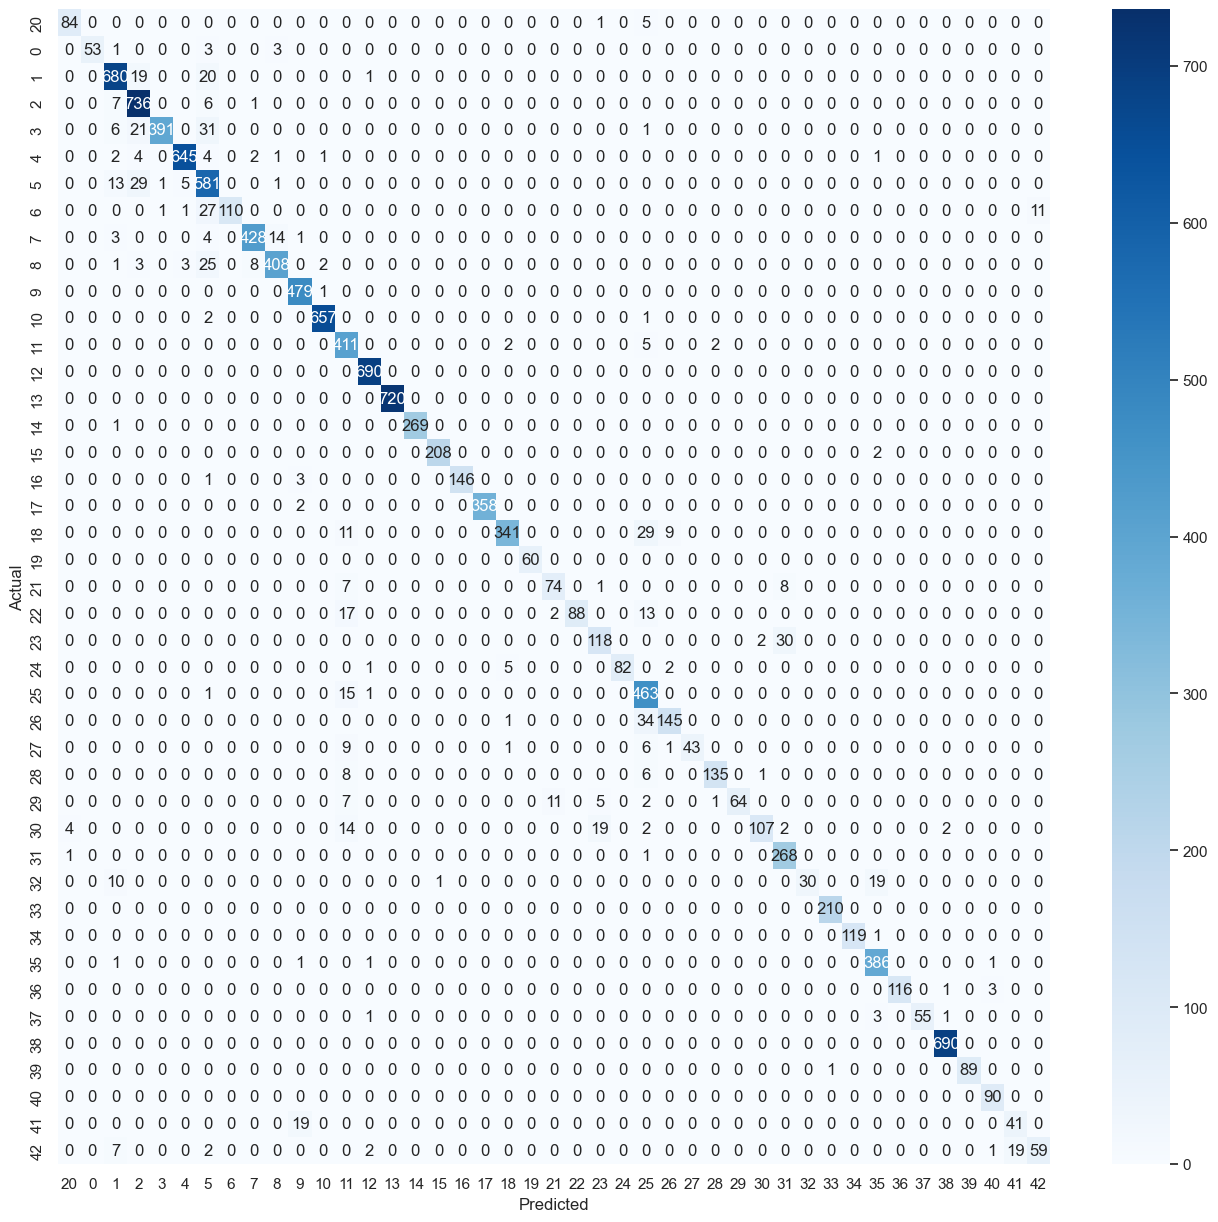

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
cm = confusion_matrix(y_test, y_pred, labels=df['ClassId'].unique())
sns.set(rc={"figure.figsize":(16, 15)}) 
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels= df['ClassId'].unique(), yticklabels=df['ClassId'].unique())
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

<a id='result'></a>